# 120: Kmerseek-Only Ortholog Pairs — Conservative Multiple Testing (Bonferroni N_TOTAL)

Conservative re-analysis of notebook 119. The key change: **Kmerseek significance is called
using Bonferroni correction over all possible human × mouse protein comparisons**, not just the
18.8 M pairs that shared ≥1 k-mer.

Pairs with zero k-mer overlap have Poisson p = 1.0 and are never significant; excluding them
from the denominator makes the raw-p < 0.05 threshold ~23× less stringent than it should be.

- **N_TOTAL_CONSERVATIVE** = n_unique_query_proteins × n_unique_target_proteins (from dataset)
- **Conservative threshold** = Bonferroni-corrected p < 0.05  →  raw p < 0.05 / N_TOTAL_CONSERVATIVE
- **Kmerseek TPs (conservative)**: pairs with conservative Bonferroni p < 0.05 AND true MGI ortholog
- **OrthoFinder TPs**: pairs in OrthoFinder predictions AND true MGI ortholog
- **Kmerseek-only**: Kmerseek TPs (conservative) NOT recovered by OrthoFinder

In [1]:
%pip install gprofiler-official requests -q

Note: you may need to restart the kernel to use updated packages.


In [2]:
import json
import time
from pathlib import Path

import numpy as np
import pandas as pd
import polars as pl
import matplotlib.pyplot as plt
import seaborn as sns
import requests
from scipy.stats import poisson, mannwhitneyu, fisher_exact
from statsmodels.stats.multitest import multipletests
from gprofiler import GProfiler

sns.set_style("whitegrid")

DATA_DIR = Path("/Users/olga/data/gencode/results-human-mouse-orthologs")
OF_DIR = Path("/Users/olga/data/gencode/data-for-orthofinder/OrthoFinder/Results_Mar03")

KSIZE = 24
ALPHA = 0.001

KMERSEEK_TSV = DATA_DIR / f"ortholog_evaluation.hp.k{KSIZE}.tsv.gz"
MGI_FILE = DATA_DIR / "HOM_MouseHumanSequence.rpt.gz"
OF_ORTHOLOGS_TSV = (
    OF_DIR
    / "Orthologues/Orthologues_gencode.v49.pc_translations"
    / "gencode.v49.pc_translations__v__gencode.vM38.pc_translations.tsv"
)

PREFIX = "120_"
print("Config OK")

Config OK


## Cell 1: Data Loading — Identify Kmerseek-Only Pairs

In [3]:
# --- MGI Ground Truth ---
mgi_raw = pl.read_csv(
    str(MGI_FILE),
    separator="\t",
    infer_schema_length=10000,
    null_values=["", "NA"],
)
print(f"MGI raw shape: {mgi_raw.shape}")

human_rows = (
    mgi_raw
    .filter(pl.col("NCBI Taxon ID") == 9606)
    .select(["DB Class Key", "Symbol"])
    .rename({"Symbol": "human_symbol"})
)
mouse_rows = (
    mgi_raw
    .filter(pl.col("NCBI Taxon ID") == 10090)
    .select(["DB Class Key", "Symbol"])
    .rename({"Symbol": "mouse_symbol"})
)

mgi_pairs = (
    human_rows
    .join(mouse_rows, on="DB Class Key", how="inner")
    .with_columns([
        pl.col("human_symbol").str.to_uppercase().alias("human_upper"),
        pl.col("mouse_symbol").str.to_uppercase().alias("mouse_upper"),
    ])
)

mgi_ortholog_set = set(
    zip(mgi_pairs["human_upper"].to_list(), mgi_pairs["mouse_upper"].to_list())
)
print(f"MGI ortholog pairs: {len(mgi_ortholog_set):,}")

MGI raw shape: (46522, 13)
MGI ortholog pairs: 24,584


In [4]:
# --- Kmerseek Data (load with Polars) ---
USECOLS = [
    "query_name", "target_name",
    "jaccard", "containment", "n_intersecting_hashes", "expected_shared_kmers",
    "prob_overlap", "enrichment", "query_tfidf", "mean_matched_kmer_freq",
    "human_gene", "mouse_gene", "is_ortholog",
]

df = pl.read_csv(
    str(KMERSEEK_TSV),
    separator="\t",
    columns=USECOLS,
    ignore_errors=True,
    null_values=["", "NA", "NaN"],
)

# Poisson p-value (scipy needs numpy arrays)
k_arr = df["n_intersecting_hashes"].to_numpy()
lam_arr = df["expected_shared_kmers"].cast(pl.Float64).fill_null(0.0).to_numpy()
poisson_p = poisson.sf(k_arr - 1, np.maximum(lam_arr, 1e-300))

# --- Conservative multiple testing corrections ---
# N_TOTAL = all possible pairwise comparisons (lower bound: unique proteins in matched pairs)
N_HUMAN = df["query_name"].n_unique()
N_MOUSE = df["target_name"].n_unique()
N_TOTAL_CONSERVATIVE = N_HUMAN * N_MOUSE
BONF_THRESHOLD = ALPHA / N_TOTAL_CONSERVATIVE

print(f"Unique human proteins in data: {N_HUMAN:,}")
print(f"Unique mouse proteins in data: {N_MOUSE:,}")
print(f"N_TOTAL_CONSERVATIVE:          {N_TOTAL_CONSERVATIVE:,}")
print(f"Conservative Bonferroni raw p threshold: {BONF_THRESHOLD:.3e}")
print(f"  (vs raw p<0.05: {ALPHA / BONF_THRESHOLD:.0f}x less stringent than conservative)")


def _bh_conservative(p_values: np.ndarray, m_total: int) -> np.ndarray:
    """BH FDR adjustment using m_total as the full denominator (including untested pairs).
    Avoids memory-intensive padding by computing the adjusted p-values directly."""
    n = len(p_values)
    order = np.argsort(p_values)
    adj = p_values[order] * m_total / np.arange(1, n + 1)
    adj = np.minimum.accumulate(adj[::-1])[::-1]
    result = np.empty(n)
    result[order] = np.minimum(adj, 1.0)
    return result


def _by_conservative(p_values: np.ndarray, m_total: int) -> np.ndarray:
    """BY FDR adjustment (valid under arbitrary dependence) using m_total total comparisons.
    c_m = sum(1/i, i=1..m) ≈ ln(m) + γ (Euler-Mascheroni constant) for large m."""
    c_m = np.log(m_total) + 0.5772156649015329
    n = len(p_values)
    order = np.argsort(p_values)
    adj = p_values[order] * m_total * c_m / np.arange(1, n + 1)
    adj = np.minimum.accumulate(adj[::-1])[::-1]
    result = np.empty(n)
    result[order] = np.minimum(adj, 1.0)
    return result


print("Computing conservative BH and BY adjustments...")
bonf_conservative = np.clip(poisson_p * N_TOTAL_CONSERVATIVE, 0, 1)
bh_conservative   = _bh_conservative(poisson_p, N_TOTAL_CONSERVATIVE)
by_conservative   = _by_conservative(poisson_p, N_TOTAL_CONSERVATIVE)

# c_m for BY (for reporting)
c_m = np.log(N_TOTAL_CONSERVATIVE) + 0.5772156649015329
print(f"BY c_m (harmonic number ≈ ln(N)+γ): {c_m:.2f}  → BY is {c_m:.1f}x more conservative than BH")

df = df.with_columns([
    pl.Series("poisson_p",                   poisson_p),
    pl.Series("poisson_p_bonf_conservative", bonf_conservative),
    pl.Series("poisson_p_bh_conservative",   bh_conservative),
    pl.Series("poisson_p_by_conservative",   by_conservative),
])

df = df.with_columns([
    pl.col("human_gene").str.to_uppercase().alias("human_upper"),
    pl.col("mouse_gene").str.to_uppercase().alias("mouse_upper"),
])

is_mgi = [
    (h, m) in mgi_ortholog_set
    for h, m in zip(df["human_upper"].to_list(), df["mouse_upper"].to_list())
]
df = df.with_columns(pl.Series("is_mgi_ortholog", is_mgi))

print(f"\nLoaded: {len(df):,} rows  |  MGI orthologs: {df['is_mgi_ortholog'].sum():,}")
print(f"Raw p<0.05:                  {(df['poisson_p'] < ALPHA).sum():,} pairs")
print(f"Conservative Bonf p<0.05:   {(df['poisson_p_bonf_conservative'] < ALPHA).sum():,} pairs")
print(f"Conservative BH p<0.05:     {(df['poisson_p_bh_conservative'] < ALPHA).sum():,} pairs")
print(f"Conservative BY p<0.05:     {(df['poisson_p_by_conservative'] < ALPHA).sum():,} pairs")

Unique human proteins in data: 19,712
Unique mouse proteins in data: 21,044
N_TOTAL_CONSERVATIVE:          414,819,328
Conservative Bonferroni raw p threshold: 2.411e-12
  (vs raw p<0.05: 414819328x less stringent than conservative)
Computing conservative BH and BY adjustments...
BY c_m (harmonic number ≈ ln(N)+γ): 20.42  → BY is 20.4x more conservative than BH

Loaded: 18,803,790 rows  |  MGI orthologs: 693,750
Raw p<0.05:                  14,858,527 pairs
Conservative Bonf p<0.05:   7,187,817 pairs
Conservative BH p<0.05:     12,874,614 pairs
Conservative BY p<0.05:     11,175,617 pairs


In [5]:
# --- OrthoFinder Predictions ---
def parse_gene_from_id(protein_id: str) -> str:
    parts = protein_id.split("|")
    return parts[-2] if len(parts) >= 2 else protein_id


of_raw = pl.read_csv(str(OF_ORTHOLOGS_TSV), separator="\t", infer_schema_length=10000)
human_col = "gencode.v49.pc_translations"
mouse_col = "gencode.vM38.pc_translations"

of_pairs = set()
for h_field, m_field in zip(of_raw[human_col].to_list(), of_raw[mouse_col].to_list()):
    humans = [x.strip() for x in str(h_field).split(",") if x.strip() and x.strip() != "nan"]
    mice = [x.strip() for x in str(m_field).split(",") if x.strip() and x.strip() != "nan"]
    for h in humans:
        for m in mice:
            of_pairs.add((parse_gene_from_id(h).upper(), parse_gene_from_id(m).upper()))

print(f"OrthoFinder gene-level pairs: {len(of_pairs):,}")

is_of = [
    (h, m) in of_pairs
    for h, m in zip(df["human_upper"].to_list(), df["mouse_upper"].to_list())
]
df = df.with_columns(pl.Series("is_orthofinder", is_of))
print(f"OrthoFinder predictions in sample: {df['is_orthofinder'].sum():,}")

OrthoFinder gene-level pairs: 24,301
OrthoFinder predictions in sample: 694,619


In [6]:
# --- Identify Kmerseek-Only and Background Sets ---
# Use conservative Bonferroni threshold (Bonferroni-corrected p < 0.05 over N_HUMAN * N_MOUSE comparisons)
df = df.with_columns((pl.col("poisson_p_bonf_conservative") < ALPHA).alias("kmerseek_pred"))

kmerseek_tps = df.filter(pl.col("kmerseek_pred") & pl.col("is_mgi_ortholog"))
orthofinder_tps = df.filter(pl.col("is_orthofinder") & pl.col("is_mgi_ortholog"))

# Kmerseek-only: found by Kmerseek (conservative Bonferroni) but not OrthoFinder
kmerseek_only = df.filter(
    pl.col("kmerseek_pred") & pl.col("is_mgi_ortholog") & ~pl.col("is_orthofinder")
)
# Background: all OrthoFinder TPs
background = df.filter(pl.col("is_orthofinder") & pl.col("is_mgi_ortholog"))

# --- Comparison across all thresholds ---
thresholds = {
    "raw p<0.05 (nb 119)":        pl.col("poisson_p") < ALPHA,
    "conservative Bonferroni":     pl.col("poisson_p_bonf_conservative") < ALPHA,
    "conservative BH (FDR)":       pl.col("poisson_p_bh_conservative") < ALPHA,
    "conservative BY (any dep.)":  pl.col("poisson_p_by_conservative") < ALPHA,
}

print("=== Kmerseek-only ortholog pairs under each threshold ===\n")
print(f"{'Threshold':<35} {'TPs':>8} {'kmerseek-only':>15}")
print("-" * 62)
for label, expr in thresholds.items():
    tps = df.filter(expr & pl.col("is_mgi_ortholog"))
    only = df.filter(expr & pl.col("is_mgi_ortholog") & ~pl.col("is_orthofinder"))
    print(f"{label:<35} {len(tps):>8,} {len(only):>15,}")
print(f"{'OrthoFinder (reference)':<35} {len(orthofinder_tps):>8,} {'—':>15}")

print(f"\nThis notebook uses: conservative Bonferroni p < {ALPHA}  (raw p < {BONF_THRESHOLD:.2e})")
print(f"Kmerseek-only pairs:  {len(kmerseek_only):,}")
print(f"Background (OrthoFinder TPs): {len(background):,}")

=== Kmerseek-only ortholog pairs under each threshold ===

Threshold                                TPs   kmerseek-only
--------------------------------------------------------------
raw p<0.05 (nb 119)                  693,439          15,321
conservative Bonferroni              692,006          14,382
conservative BH (FDR)                693,182          15,114
conservative BY (any dep.)           692,881          14,918
OrthoFinder (reference)              678,255               —

This notebook uses: conservative Bonferroni p < 0.001  (raw p < 2.41e-12)
Kmerseek-only pairs:  14,382
Background (OrthoFinder TPs): 678,255


## Metric Evaluation: Compare 13 Scoring Approaches

Evaluate which score best discriminates true MGI orthologs from non-orthologs among all pairs with k-mer overlap (k=24). Pairs without any overlap are not in the dataset; among scored pairs, all 13 metrics are computed and compared using AUROC and AUPRC.

**Hypothesis:** `score_enr_cont_freq` (enrichment × containment / mean_matched_kmer_freq) will outperform raw enrichment/containment and p-value-based scores by penalizing matches driven by high-frequency (non-specific) k-mers.

| Score | Description |
|---|---|
| `score_enr_cont_freq` | enrichment × containment / mean_matched_kmer_freq |
| `score_enr_cont` | enrichment × containment |
| `score_neglogp_cont` | −log₁₀(p) × containment |
| `score_tfidf_cont` | query_tfidf × containment |
| `score_neglogp` | −log₁₀(p) |
| `score_bonf_neglogp` | −log₁₀(p × N_bonf) |
| `score_bonf_neglogp_cont` | −log₁₀(p × N_bonf) × containment |
| `score_bh_neglogq` | −log₁₀(q_BH) |
| `score_bh_neglogq_cont` | −log₁₀(q_BH) × containment |
| `query_tfidf` | query TF-IDF (standalone) |
| `enrichment` | raw enrichment |
| `containment` | raw containment |
| `jaccard` | raw Jaccard |

In [7]:
from sklearn.metrics import roc_auc_score, average_precision_score, roc_curve, precision_recall_curve

SCORE_COLS = [
    "score_enr_cont_freq",
    "score_enr_cont",
    "score_neglogp_cont",
    "score_tfidf_cont",
    "score_neglogp",
    "score_bonf_neglogp",
    "score_bonf_neglogp_cont",
    "score_bh_neglogq",
    "score_bh_neglogq_cont",
    "query_tfidf",
    "enrichment",
    "containment",
    "jaccard",
]
SCORE_LABELS = {
    "score_enr_cont_freq":     "enrichment x containment / freq",
    "score_enr_cont":          "enrichment x containment",
    "score_neglogp_cont":      "-log10(p) x containment",
    "score_tfidf_cont":        "query_tfidf x containment",
    "score_neglogp":           "-log10(p)",
    "score_bonf_neglogp":      "-log10(p*N_bonf)",
    "score_bonf_neglogp_cont": "-log10(p*N_bonf) x containment",
    "score_bh_neglogq":        "-log10(q_BH)",
    "score_bh_neglogq_cont":   "-log10(q_BH) x containment",
    "query_tfidf":             "query_tfidf",
    "enrichment":              "enrichment",
    "containment":             "containment",
    "jaccard":                 "jaccard",
}

# --- Extract numpy arrays ---
enr    = df["enrichment"].fill_null(0.0).to_numpy()
cont   = df["containment"].fill_null(0.0).to_numpy()
freq   = df["mean_matched_kmer_freq"].fill_null(0.0).to_numpy()
tfidf  = df["query_tfidf"].fill_null(0.0).to_numpy()
jaccard = df["jaccard"].fill_null(0.0).to_numpy()

p_raw  = np.clip(df["poisson_p"].fill_null(1.0).to_numpy(),                   np.finfo(float).tiny, 1.0)
p_bonf = np.clip(df["poisson_p_bonf_conservative"].fill_null(1.0).to_numpy(), np.finfo(float).tiny, 1.0)
p_bh   = np.clip(df["poisson_p_bh_conservative"].fill_null(1.0).to_numpy(),   np.finfo(float).tiny, 1.0)

# safe division: enr*cont / freq, 0 where freq=0
with np.errstate(divide="ignore", invalid="ignore"):
    score_enr_cont_freq = np.where(freq > 0, enr * cont / freq, 0.0)

scores = {
    "score_enr_cont_freq":     score_enr_cont_freq,
    "score_enr_cont":          enr * cont,
    "score_neglogp_cont":      -np.log10(p_raw) * cont,
    "score_tfidf_cont":        tfidf * cont,
    "score_neglogp":           -np.log10(p_raw),
    "score_bonf_neglogp":      -np.log10(p_bonf),
    "score_bonf_neglogp_cont": -np.log10(p_bonf) * cont,
    "score_bh_neglogq":        -np.log10(p_bh),
    "score_bh_neglogq_cont":   -np.log10(p_bh) * cont,
    "query_tfidf":             tfidf,
    "enrichment":              enr,
    "containment":             cont,
    "jaccard":                 jaccard,
}

y_true = df["is_mgi_ortholog"].to_numpy().astype(int)
print(f"Evaluation set: {len(y_true):,} pairs with k-mer overlap")
print(f"  Positives (MGI orthologs): {y_true.sum():,}  ({100*y_true.mean():.2f}%)")
print(f"  Negatives:                 {(1-y_true).sum():,}")

Evaluation set: 18,803,790 pairs with k-mer overlap
  Positives (MGI orthologs): 693,750  (3.69%)
  Negatives:                 18,110,040


In [8]:
# --- AUROC and AUPRC for each metric ---
results = []
for name, s in scores.items():
    s_clean = np.nan_to_num(s, nan=0.0, posinf=np.nanmax(s[np.isfinite(s)]), neginf=0.0)
    auroc = roc_auc_score(y_true, s_clean)
    auprc = average_precision_score(y_true, s_clean)
    results.append({"metric": name, "label": SCORE_LABELS[name], "AUROC": auroc, "AUPRC": auprc})

results_df = pd.DataFrame(results).sort_values("AUPRC", ascending=False).reset_index(drop=True)
results_df["rank"] = results_df.index + 1
print("=== Metric Ranking by AUPRC (primary) and AUROC ===\n")
print(results_df[["rank", "metric", "AUPRC", "AUROC"]].to_string(index=False, float_format="{:.4f}".format))

hyp_row = results_df[results_df["metric"] == "score_enr_cont_freq"].iloc[0]
print(f"\n→ score_enr_cont_freq rank: {int(hyp_row['rank'])} / {len(results_df)}"
      f"  (AUPRC={hyp_row['AUPRC']:.4f}, AUROC={hyp_row['AUROC']:.4f})")

=== Metric Ranking by AUPRC (primary) and AUROC ===

 rank                  metric  AUPRC  AUROC
    1 score_bonf_neglogp_cont 0.7626 0.9801
    2   score_bh_neglogq_cont 0.7583 0.9795
    3      score_neglogp_cont 0.7575 0.9794
    4                 jaccard 0.7518 0.9785
    5          score_enr_cont 0.7440 0.9756
    6        score_bh_neglogq 0.7312 0.9834
    7      score_bonf_neglogp 0.7311 0.9832
    8           score_neglogp 0.7310 0.9833
    9              enrichment 0.7300 0.9730
   10        score_tfidf_cont 0.7197 0.9665
   11             containment 0.7090 0.9685
   12     score_enr_cont_freq 0.6900 0.9542
   13             query_tfidf 0.0732 0.5680

→ score_enr_cont_freq rank: 12 / 13  (AUPRC=0.6900, AUROC=0.9542)


Saved: /Users/olga/data/gencode/results-human-mouse-orthologs/120_metric_comparison_pr_roc.png


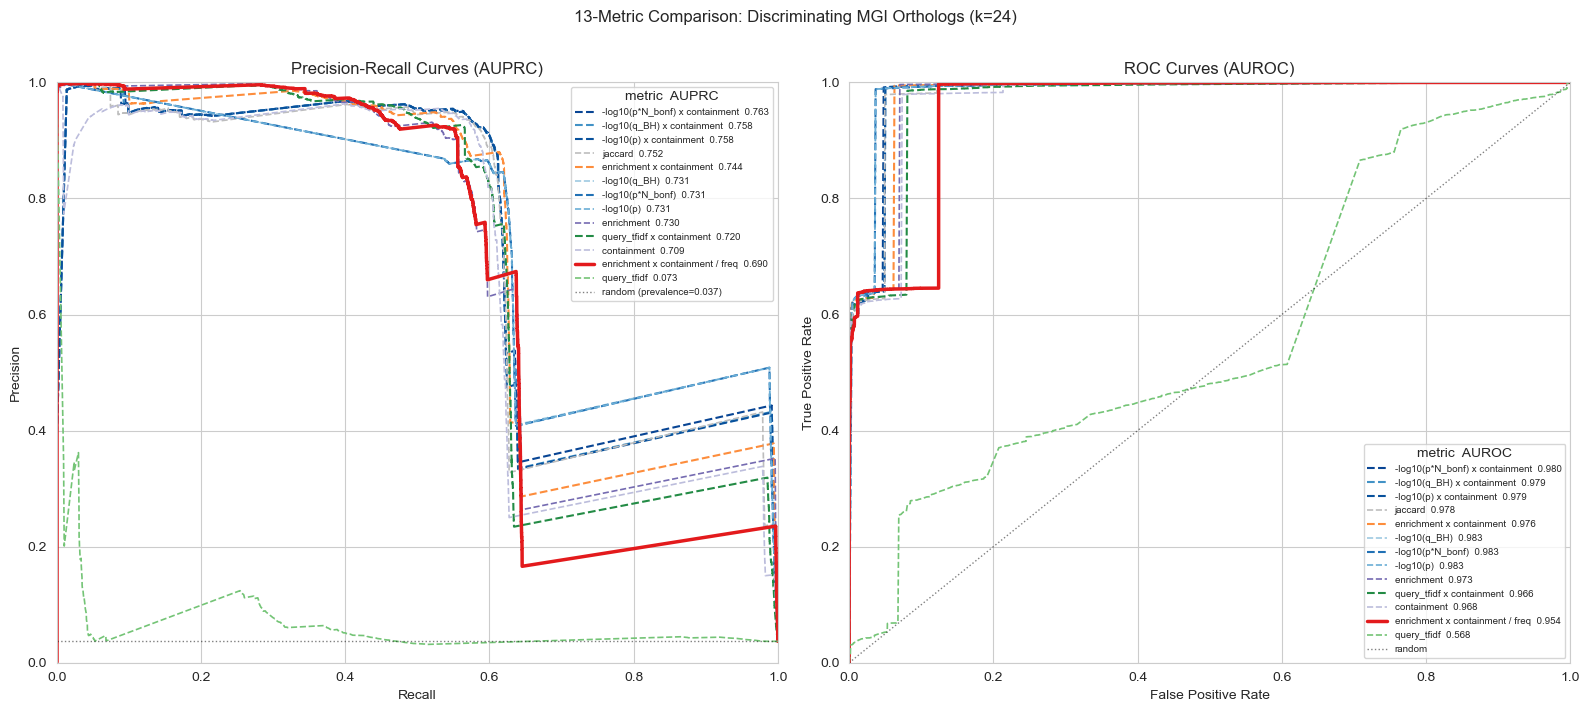

In [9]:
# --- PR and ROC curves for all 13 metrics ---
# Color groups: freq-composite (red), enr/cont composites (orange), p-value (blue family),
# tfidf (green family), raw baselines (grey/purple)
PALETTE = {
    "score_enr_cont_freq":     ("#e31a1c", 2.5),   # red bold — hypothesis
    "score_enr_cont":          ("#fd8d3c", 1.5),   # orange
    "score_neglogp_cont":      ("#08519c", 1.5),   # dark blue
    "score_tfidf_cont":        ("#238b45", 1.5),   # dark green
    "score_neglogp":           ("#6baed6", 1.2),   # light blue
    "score_bonf_neglogp":      ("#2171b5", 1.5),   # medium blue
    "score_bonf_neglogp_cont": ("#084594", 1.5),   # navy
    "score_bh_neglogq":        ("#9ecae1", 1.2),   # pale blue
    "score_bh_neglogq_cont":   ("#4292c6", 1.5),   # sky blue
    "query_tfidf":             ("#74c476", 1.2),   # light green
    "enrichment":              ("#756bb1", 1.2),   # purple
    "containment":             ("#bcbddc", 1.2),   # lavender
    "jaccard":                 ("#bdbdbd", 1.2),   # grey
}

fig, axes = plt.subplots(1, 2, figsize=(16, 7))
ordered_metrics = results_df["metric"].tolist()

for name in ordered_metrics:
    s = scores[name]
    s_clean = np.nan_to_num(s, nan=0.0, posinf=np.nanmax(s[np.isfinite(s)]), neginf=0.0)
    color, lw = PALETTE[name]
    label = SCORE_LABELS[name]
    auprc = results_df.loc[results_df["metric"] == name, "AUPRC"].iloc[0]
    auroc = results_df.loc[results_df["metric"] == name, "AUROC"].iloc[0]
    ls = "-" if name == "score_enr_cont_freq" else "--"

    prec, rec, _ = precision_recall_curve(y_true, s_clean)
    axes[0].plot(rec, prec, color=color, lw=lw, ls=ls,
                 label=f"{label}  {auprc:.3f}")

    fpr, tpr, _ = roc_curve(y_true, s_clean)
    axes[1].plot(fpr, tpr, color=color, lw=lw, ls=ls,
                 label=f"{label}  {auroc:.3f}")

prevalence = y_true.mean()
axes[0].axhline(prevalence, color="black", lw=1, ls=":", alpha=0.5,
                label=f"random (prevalence={prevalence:.3f})")
axes[0].set_xlabel("Recall"); axes[0].set_ylabel("Precision")
axes[0].set_title("Precision-Recall Curves (AUPRC)")
axes[0].legend(fontsize=7, loc="upper right", title="metric  AUPRC")
axes[0].set_xlim(0, 1); axes[0].set_ylim(0, 1)

axes[1].plot([0, 1], [0, 1], "k:", lw=1, alpha=0.5, label="random")
axes[1].set_xlabel("False Positive Rate"); axes[1].set_ylabel("True Positive Rate")
axes[1].set_title("ROC Curves (AUROC)")
axes[1].legend(fontsize=7, loc="lower right", title="metric  AUROC")
axes[1].set_xlim(0, 1); axes[1].set_ylim(0, 1)

plt.suptitle("13-Metric Comparison: Discriminating MGI Orthologs (k=24)", fontsize=12, y=1.01)
plt.tight_layout()
out_path = DATA_DIR / f"{PREFIX}metric_comparison_pr_roc.png"
plt.savefig(out_path, dpi=150, bbox_inches="tight")
print(f"Saved: {out_path}")
plt.show()

Saved: /Users/olga/data/gencode/results-human-mouse-orthologs/120_metric_comparison_bar.png


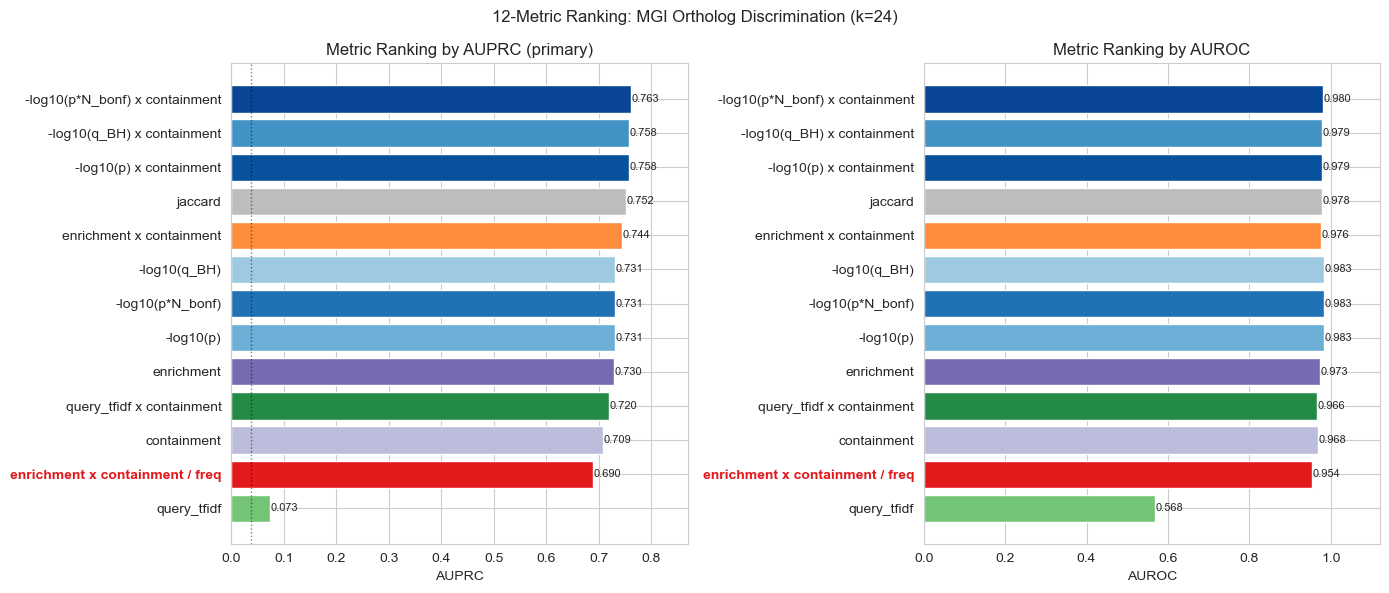

In [10]:
# --- Bar chart: AUPRC and AUROC side by side ---
fig, axes = plt.subplots(1, 2, figsize=(14, 6))

colors = [PALETTE[m][0] for m in results_df["metric"]]
labels = [SCORE_LABELS[m] for m in results_df["metric"]]

for ax, col, title in zip(axes, ["AUPRC", "AUROC"], ["AUPRC (primary)", "AUROC"]):
    bars = ax.barh(labels, results_df[col], color=colors, edgecolor="white")
    ax.set_xlabel(col)
    ax.set_title(f"Metric Ranking by {title}")
    ax.invert_yaxis()
    for bar, val in zip(bars, results_df[col]):
        ax.text(val + 0.001, bar.get_y() + bar.get_height() / 2,
                f"{val:.3f}", va="center", fontsize=8)
    if col == "AUPRC":
        ax.axvline(prevalence, color="black", lw=1, ls=":", alpha=0.5)
    ax.set_xlim(0, max(results_df[col]) * 1.14)

# Highlight hypothesis metric label
hyp_label = SCORE_LABELS["score_enr_cont_freq"]
for ax in axes:
    for lbl in ax.get_yticklabels():
        if lbl.get_text() == hyp_label:
            lbl.set_fontweight("bold")
            lbl.set_color("#e31a1c")

plt.suptitle("12-Metric Ranking: MGI Ortholog Discrimination (k=24)", fontsize=12)
plt.tight_layout()
out_path = DATA_DIR / f"{PREFIX}metric_comparison_bar.png"
plt.savefig(out_path, dpi=150, bbox_inches="tight")
print(f"Saved: {out_path}")
plt.show()

## Metric Evaluation Across All K-sizes (k=15–30)

Repeat the 13-metric evaluation for every available k-size to see how discriminative power changes with k.

In [11]:
def evaluate_ksize(ksize: int) -> list[dict] | None:
    """Load kmerseek TSV for one k-size, compute 13 scores, return AUROC/AUPRC per metric.
    Returns None if the file is empty."""
    tsv = DATA_DIR / f"ortholog_evaluation.hp.k{ksize}.tsv.gz"
    if tsv.stat().st_size == 0:
        return None

    try:
        kdf = pl.read_csv(
            str(tsv),
            separator="\t",
            columns=USECOLS,
            ignore_errors=True,
            null_values=["", "NA", "NaN"],
            raise_if_empty=False,
        )
    except Exception as e:
        print(f"  k={ksize:2d}  (skipped: {e})")
        return None
    if len(kdf) == 0:
        return None

    # Poisson p-value
    k_arr = kdf["n_intersecting_hashes"].to_numpy()
    lam_arr = kdf["expected_shared_kmers"].cast(pl.Float64).fill_null(0.0).to_numpy()
    p = poisson.sf(k_arr - 1, np.maximum(lam_arr, 1e-300))

    n_h = kdf["query_name"].n_unique()
    n_m = kdf["target_name"].n_unique()
    n_total = n_h * n_m

    p_bonf_arr = np.clip(p * n_total, 0, 1)
    p_bh_arr   = _bh_conservative(p, n_total)

    kdf = kdf.with_columns([
        pl.Series("poisson_p", p),
        pl.Series("poisson_p_bonf_conservative", p_bonf_arr),
        pl.Series("poisson_p_bh_conservative",   p_bh_arr),
        pl.col("human_gene").str.to_uppercase().alias("human_upper"),
        pl.col("mouse_gene").str.to_uppercase().alias("mouse_upper"),
    ])

    is_mgi_k = [
        (h, m) in mgi_ortholog_set
        for h, m in zip(kdf["human_upper"].to_list(), kdf["mouse_upper"].to_list())
    ]
    kdf = kdf.with_columns(pl.Series("is_mgi_ortholog", is_mgi_k))

    enr_k   = kdf["enrichment"].fill_null(0.0).to_numpy()
    cont_k  = kdf["containment"].fill_null(0.0).to_numpy()
    freq_k  = kdf["mean_matched_kmer_freq"].fill_null(0.0).to_numpy()
    tfidf_k = kdf["query_tfidf"].fill_null(0.0).to_numpy()
    jac_k   = kdf["jaccard"].fill_null(0.0).to_numpy()

    eps = np.finfo(float).tiny
    p_raw_k  = np.clip(kdf["poisson_p"].fill_null(1.0).to_numpy(),                   eps, 1.0)
    p_bonf_k = np.clip(kdf["poisson_p_bonf_conservative"].fill_null(1.0).to_numpy(), eps, 1.0)
    p_bh_k   = np.clip(kdf["poisson_p_bh_conservative"].fill_null(1.0).to_numpy(),   eps, 1.0)

    with np.errstate(divide="ignore", invalid="ignore"):
        s_ecf = np.where(freq_k > 0, enr_k * cont_k / freq_k, 0.0)

    k_scores = {
        "score_enr_cont_freq":     s_ecf,
        "score_enr_cont":          enr_k * cont_k,
        "score_neglogp_cont":      -np.log10(p_raw_k) * cont_k,
        "score_tfidf_cont":        tfidf_k * cont_k,
        "score_neglogp":           -np.log10(p_raw_k),
        "score_bonf_neglogp":      -np.log10(p_bonf_k),
        "score_bonf_neglogp_cont": -np.log10(p_bonf_k) * cont_k,
        "score_bh_neglogq":        -np.log10(p_bh_k),
        "score_bh_neglogq_cont":   -np.log10(p_bh_k) * cont_k,
        "query_tfidf":             tfidf_k,
        "enrichment":              enr_k,
        "containment":             cont_k,
        "jaccard":                 jac_k,
    }

    y_k = kdf["is_mgi_ortholog"].to_numpy().astype(int)
    rows = []
    for name, s in k_scores.items():
        s_clean = np.nan_to_num(s, nan=0.0, posinf=np.nanmax(s[np.isfinite(s)]), neginf=0.0)
        rows.append({
            "ksize":       ksize,
            "metric":      name,
            "label":       SCORE_LABELS[name],
            "AUROC":       roc_auc_score(y_k, s_clean),
            "AUPRC":       average_precision_score(y_k, s_clean),
            "n_pairs":     len(y_k),
            "n_positives": int(y_k.sum()),
        })
    return rows


KSIZES = list(range(15, 31))
print(f"Evaluating {len(SCORE_COLS)} metrics × {len(KSIZES)} k-sizes (skipping empty files) …")
all_rows = []
for k in KSIZES:
    rows = evaluate_ksize(k)
    if rows is None:
        print(f"  k={k:2d}  (empty, skipped)")
        continue
    all_rows.extend(rows)
    print(f"  k={k:2d}  pairs={rows[0]['n_pairs']:,}  positives={rows[0]['n_positives']:,}")

sweep_df = pd.DataFrame(all_rows)
KSIZES_AVAIL = sorted(sweep_df["ksize"].unique())
print(f"\nDone. Available k-sizes: {KSIZES_AVAIL}  |  Total evaluations: {len(sweep_df)}")


Evaluating 13 metrics × 16 k-sizes (skipping empty files) …
  k=15  (skipped: unable to find column "query_name"; valid columns: [])
  k=15  (empty, skipped)
  k=16  (skipped: unable to find column "query_name"; valid columns: [])
  k=16  (empty, skipped)
  k=17  (skipped: unable to find column "query_name"; valid columns: [])
  k=17  (empty, skipped)
  k=18  (skipped: unable to find column "query_name"; valid columns: [])
  k=18  (empty, skipped)
  k=19  (skipped: unable to find column "query_name"; valid columns: [])
  k=19  (empty, skipped)
  k=20  (skipped: unable to find column "query_name"; valid columns: [])
  k=20  (empty, skipped)
  k=21  (skipped: unable to find column "query_name"; valid columns: [])
  k=21  (empty, skipped)
  k=22  (skipped: unable to find column "query_name"; valid columns: [])
  k=22  (empty, skipped)
  k=23  (skipped: unable to find column "query_name"; valid columns: [])
  k=23  (empty, skipped)
  k=24  pairs=18,803,790  positives=693,750
  k=25  pairs=

Saved: /Users/olga/data/gencode/results-human-mouse-orthologs/120_metric_comparison_ksize_sweep.png


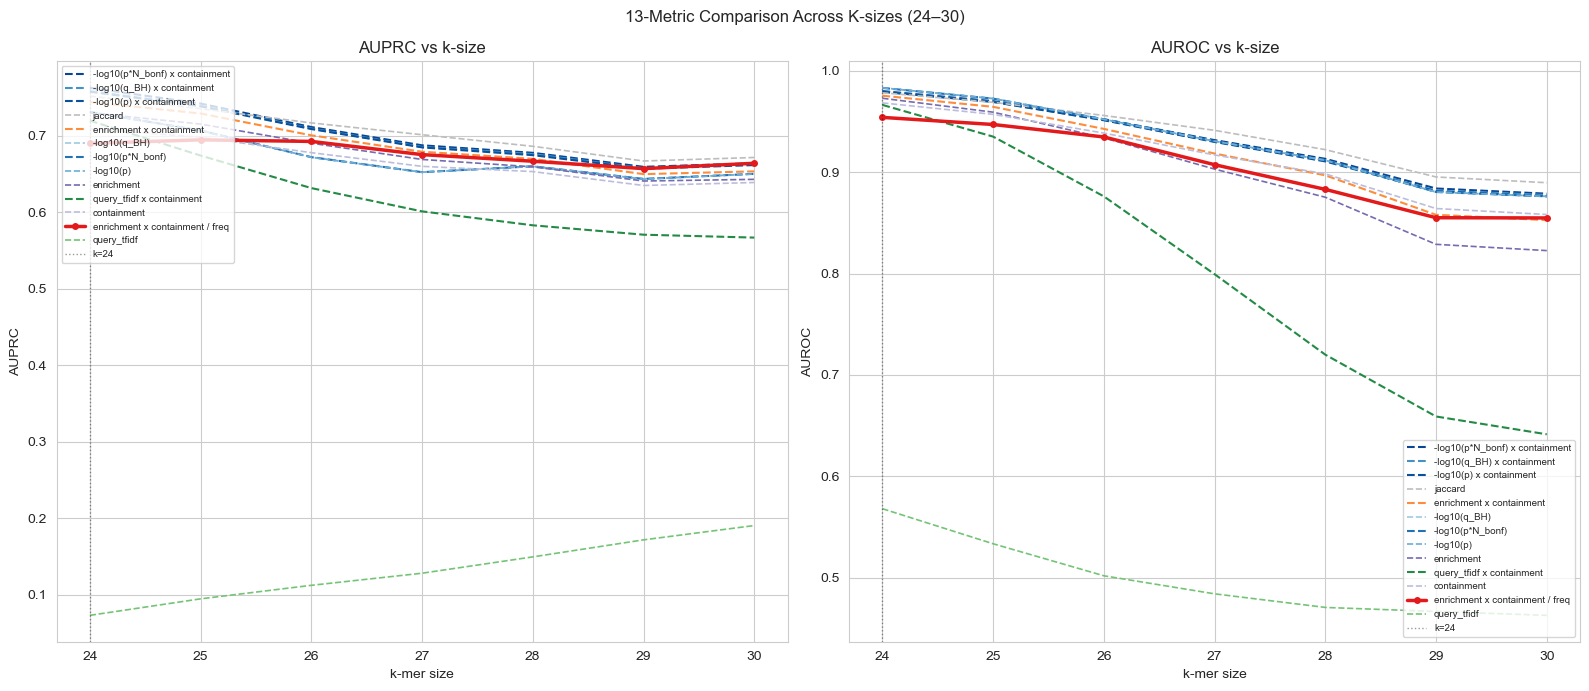


=== Best metric by AUPRC at each k-size ===
 ksize                  metric  AUPRC  AUROC
    24 score_bonf_neglogp_cont 0.7626 0.9801
    25 score_bonf_neglogp_cont 0.7420 0.9702
    26                 jaccard 0.7168 0.9561
    27                 jaccard 0.7013 0.9414
    28                 jaccard 0.6862 0.9223
    29                 jaccard 0.6670 0.8954
    30                 jaccard 0.6716 0.8897


In [12]:
# --- Line plots: AUPRC and AUROC vs k-size, one line per metric ---
fig, axes = plt.subplots(1, 2, figsize=(16, 7), sharey=False)

metric_order = results_df["metric"].tolist()  # ordered by AUPRC at k=24

for metric in metric_order:
    sub = sweep_df[sweep_df["metric"] == metric].sort_values("ksize")
    color, lw = PALETTE[metric]
    label = SCORE_LABELS[metric]
    ls = "-" if metric == "score_enr_cont_freq" else "--"
    marker = "o" if metric == "score_enr_cont_freq" else None
    ms = 4 if marker else None

    axes[0].plot(sub["ksize"], sub["AUPRC"], color=color, lw=lw, ls=ls,
                 marker=marker, markersize=ms, label=label)
    axes[1].plot(sub["ksize"], sub["AUROC"], color=color, lw=lw, ls=ls,
                 marker=marker, markersize=ms, label=label)

for ax in axes:
    if 24 in KSIZES_AVAIL:
        ax.axvline(24, color="black", lw=1, ls=":", alpha=0.4, label="k=24")
    ax.set_xlabel("k-mer size")
    ax.set_xticks(KSIZES_AVAIL)

axes[0].set_ylabel("AUPRC")
axes[0].set_title("AUPRC vs k-size")
axes[0].legend(fontsize=7, loc="upper left")

axes[1].set_ylabel("AUROC")
axes[1].set_title("AUROC vs k-size")
axes[1].legend(fontsize=7, loc="lower right")

plt.suptitle(f"13-Metric Comparison Across K-sizes ({KSIZES_AVAIL[0]}–{KSIZES_AVAIL[-1]})", fontsize=12)
plt.tight_layout()
out_path = DATA_DIR / f"{PREFIX}metric_comparison_ksize_sweep.png"
plt.savefig(out_path, dpi=150, bbox_inches="tight")
print(f"Saved: {out_path}")
plt.show()

print("\n=== Best metric by AUPRC at each k-size ===")
best = sweep_df.loc[sweep_df.groupby("ksize")["AUPRC"].idxmax(), ["ksize", "metric", "AUPRC", "AUROC"]]
print(best.to_string(index=False, float_format="{:.4f}".format))

In [13]:
# Extract Ensembl protein/gene IDs from pipe-delimited GENCODE name
# Format: ENSP...|ENST...|ENSG...|...|gene_name|length

def extract_ids(name_series: pl.Series) -> pl.DataFrame:
    rows = []
    for name in name_series.to_list():
        parts = str(name).split("|")
        protein_id = parts[0].split(".")[0] if parts else ""
        gene_id = parts[2].split(".")[0] if len(parts) > 2 else ""
        gene_name = parts[-2] if len(parts) >= 2 else ""
        rows.append({"protein_id": protein_id, "gene_id": gene_id, "gene_name": gene_name})
    return pl.DataFrame(rows)


def prepare_set_df(subset: pl.DataFrame, label: str) -> pl.DataFrame:
    human_ids = extract_ids(subset["query_name"])
    mouse_ids = extract_ids(subset["target_name"])
    return subset.with_columns([
        human_ids["protein_id"].alias("human_protein_id"),
        human_ids["gene_id"].alias("human_gene_id"),
        human_ids["gene_name"].alias("human_gene_name"),
        mouse_ids["protein_id"].alias("mouse_protein_id"),
        mouse_ids["gene_id"].alias("mouse_gene_id"),
        mouse_ids["gene_name"].alias("mouse_gene_name"),
        pl.lit(label).alias("set_label"),
    ])


kmerseek_only_df = prepare_set_df(kmerseek_only, "kmerseek_only")
background_df = prepare_set_df(background, "background")

print("Kmerseek-only sample (conservative threshold):")
print(kmerseek_only_df.select(["human_gene_name", "mouse_gene_name", "human_protein_id", "human_gene_id", "poisson_p", "poisson_p_bonf_conservative"]).head(5))

out_path = DATA_DIR / f"{PREFIX}kmerseek_only_pairs.csv"
kmerseek_only_df.write_csv(str(out_path))
print(f"\nSaved {len(kmerseek_only_df):,} Kmerseek-only pairs to {out_path}")

Kmerseek-only sample (conservative threshold):
shape: (5, 6)
┌─────────────────┬────────────────┬────────────────┬────────────────┬────────────┬────────────────┐
│ human_gene_name ┆ mouse_gene_nam ┆ human_protein_ ┆ human_gene_id  ┆ poisson_p  ┆ poisson_p_bonf │
│ ---             ┆ e              ┆ id             ┆ ---            ┆ ---        ┆ _conservative  │
│ str             ┆ ---            ┆ ---            ┆ str            ┆ f64        ┆ ---            │
│                 ┆ str            ┆ str            ┆                ┆            ┆ f64            │
╞═════════════════╪════════════════╪════════════════╪════════════════╪════════════╪════════════════╡
│ AADACL4         ┆ Aadacl4fm1     ┆ ENSP0000036539 ┆ ENSG0000020451 ┆ 2.1435e-82 ┆ 8.8916e-74     │
│                 ┆                ┆ 5              ┆ 8              ┆            ┆                │
│ AADACL4         ┆ Aadacl4fm1     ┆ ENSP0000036539 ┆ ENSG0000020451 ┆ 2.1435e-82 ┆ 8.8916e-74     │
│                 ┆           

## Cell 2: Map Ensembl Protein IDs to UniProt Accessions

In [14]:
def load_cache(path: Path) -> dict:
    if path.exists():
        with open(path) as f:
            return json.load(f)
    return {}


def save_cache(data: dict, path: Path):
    with open(path, "w") as f:
        json.dump(data, f)

In [15]:
UNIPROT_CACHE = DATA_DIR / f"{PREFIX}uniprot_id_mapping_cache.json"


def submit_uniprot_mapping(ids: list, from_db: str = "Ensembl_Protein", to_db: str = "UniProtKB") -> str:
    resp = requests.post(
        "https://rest.uniprot.org/idmapping/run",
        data={"from": from_db, "to": to_db, "ids": ",".join(ids)},
        timeout=60,
    )
    resp.raise_for_status()
    return resp.json().get("jobId", "")


def poll_uniprot_job(job_id: str, max_wait: int = 300) -> dict:
    status_url = f"https://rest.uniprot.org/idmapping/status/{job_id}"
    stream_url = f"https://rest.uniprot.org/idmapping/stream/{job_id}"
    waited = 0
    while waited < max_wait:
        resp = requests.get(status_url, timeout=30)
        resp.raise_for_status()
        status = resp.json()
        if "results" in status or status.get("jobStatus") == "FINISHED":
            break
        if status.get("jobStatus") in ("ERROR", "FAILURE"):
            print(f"Job failed: {status}")
            return {}
        time.sleep(5)
        waited += 5
    resp = requests.get(stream_url, timeout=120)
    resp.raise_for_status()
    return resp.json()


def batch_map_ensembl_to_uniprot(ensembl_ids: list, cache: dict, batch_size: int = 500) -> dict:
    to_query = [eid for eid in ensembl_ids if eid and eid not in cache]
    print(f"Querying {len(to_query):,} new IDs ({len(ensembl_ids) - len(to_query):,} cached)")
    for i in range(0, len(to_query), batch_size):
        batch = to_query[i : i + batch_size]
        print(f"  Batch {i // batch_size + 1}: {len(batch)} IDs ...", end=" ", flush=True)
        try:
            job_id = submit_uniprot_mapping(batch)
            if not job_id:
                continue
            result = poll_uniprot_job(job_id)
            n_mapped = 0
            for entry in result.get("results", []):
                from_id = entry.get("from", "")
                to_info = entry.get("to", {})
                accession = (
                    to_info.get("primaryAccession")
                    if isinstance(to_info, dict)
                    else str(to_info)
                )
                if accession:
                    cache[from_id] = accession
                    n_mapped += 1
            print(f"OK ({n_mapped} mapped)")
        except Exception as exc:
            print(f"ERROR: {exc}")
            time.sleep(5)
    return cache


all_human_ensp = list(set(
    kmerseek_only_df["human_protein_id"].to_list()
    + background_df["human_protein_id"].to_list()
))
all_human_ensp = [x for x in all_human_ensp if x and x.startswith("ENSP")]
print(f"Unique human ENSP IDs: {len(all_human_ensp):,}")

uniprot_cache = load_cache(UNIPROT_CACHE)
print(f"Cache has {len(uniprot_cache):,} entries")

uniprot_cache = batch_map_ensembl_to_uniprot(all_human_ensp, uniprot_cache)
save_cache(uniprot_cache, UNIPROT_CACHE)

n_mapped = sum(1 for x in all_human_ensp if x in uniprot_cache)
print(f"\nMapped {n_mapped:,}/{len(all_human_ensp):,} ({100 * n_mapped / max(len(all_human_ensp), 1):.1f}%) ENSP -> UniProt")

Unique human ENSP IDs: 16,568
Cache has 16,531 entries
Querying 46 new IDs (16,522 cached)
  Batch 1: 46 IDs ... OK (0 mapped)

Mapped 16,522/16,568 (99.7%) ENSP -> UniProt


In [16]:
ko_uniprot = [uniprot_cache.get(p) for p in kmerseek_only_df["human_protein_id"].to_list()]
bg_uniprot = [uniprot_cache.get(p) for p in background_df["human_protein_id"].to_list()]

kmerseek_only_df = kmerseek_only_df.with_columns(pl.Series("uniprot_acc", ko_uniprot))
background_df = background_df.with_columns(pl.Series("uniprot_acc", bg_uniprot))

print(f"Kmerseek-only with UniProt: {kmerseek_only_df['uniprot_acc'].drop_nulls().len():,}/{len(kmerseek_only_df):,}")
print(f"Background with UniProt:    {background_df['uniprot_acc'].drop_nulls().len():,}/{len(background_df):,}")

Kmerseek-only with UniProt: 14,370/14,382
Background with UniProt:    678,028/678,255


## Cell 3: UniProt Annotations (Subcellular Location, Transmembrane, Disorder, Length)

In [17]:
UNIPROT_ANN_CACHE = DATA_DIR / f"{PREFIX}uniprot_annotations_cache.json"

ann_session = requests.Session()
ann_session.headers["User-Agent"] = "kmerseek-ortho-characterization/1.0"


def fetch_uniprot_entry(accession: str) -> dict:
    url = f"https://rest.uniprot.org/uniprotkb/{accession}.json"
    try:
        resp = ann_session.get(url, timeout=30)
        if resp.status_code == 429:
            time.sleep(5)
            resp = ann_session.get(url, timeout=30)
        if resp.status_code == 404:
            return {}
        resp.raise_for_status()
        return resp.json()
    except Exception as exc:
        print(f"  WARN {accession}: {exc}")
        return {}


def parse_uniprot_entry(entry: dict) -> dict:
    if not entry:
        return {}
    result = {}
    result["seq_length"] = entry.get("sequence", {}).get("length")
    keywords = [kw.get("name", "") for kw in entry.get("keywords", [])]
    result["keywords"] = "; ".join(keywords)
    subloc_texts = []
    for comment in entry.get("comments", []):
        if comment.get("commentType") == "SUBCELLULAR LOCATION":
            for loc in comment.get("subcellularLocations", []):
                val = loc.get("location", {}).get("value", "")
                if val:
                    subloc_texts.append(val)
    result["subcellular_location"] = "; ".join(subloc_texts)
    combined = (result["subcellular_location"] + " " + result["keywords"]).lower()
    result["is_membrane"] = any(x in combined for x in ["membrane", "transmembrane"])
    result["is_secreted"] = any(x in combined for x in ["secreted", "extracellular"])
    result["is_nuclear"] = any(x in combined for x in ["nucleus", "nuclear"])
    tm_count = 0
    disordered = 0
    for feat in entry.get("features", []):
        ftype = feat.get("type", "")
        if ftype == "Transmembrane":
            tm_count += 1
        if ftype == "Region" and "disordered" in feat.get("description", "").lower():
            disordered += 1
    result["n_transmembrane"] = tm_count
    result["n_disordered_regions"] = disordered
    result["has_disordered_regions"] = disordered > 0
    return result


ann_cache = load_cache(UNIPROT_ANN_CACHE)
print(f"Annotation cache has {len(ann_cache):,} entries")

all_acc = list(set(
    [x for x in kmerseek_only_df["uniprot_acc"].to_list() if x]
    + [x for x in background_df["uniprot_acc"].to_list() if x]
))
to_query_ann = [a for a in all_acc if a not in ann_cache]
print(f"Total UniProt accessions: {len(all_acc):,}  |  To query: {len(to_query_ann):,}")

for i, acc in enumerate(to_query_ann):
    ann_cache[acc] = fetch_uniprot_entry(acc)
    if (i + 1) % 100 == 0:
        print(f"  {i + 1}/{len(to_query_ann)} ...")
        save_cache(ann_cache, UNIPROT_ANN_CACHE)
    time.sleep(0.1)

save_cache(ann_cache, UNIPROT_ANN_CACHE)
print(f"Done. Cache has {len(ann_cache):,} entries.")

Annotation cache has 16,504 entries
Total UniProt accessions: 16,495  |  To query: 0
Done. Cache has 16,504 entries.


In [18]:
def add_annotations(df_pl: pl.DataFrame) -> pl.DataFrame:
    rows = [
        parse_uniprot_entry(ann_cache.get(acc, {}) if acc else {})
        for acc in df_pl["uniprot_acc"].to_list()
    ]
    ann_df = pl.DataFrame({
        "seq_length": [r.get("seq_length") for r in rows],
        "keywords": [r.get("keywords", "") for r in rows],
        "subcellular_location": [r.get("subcellular_location", "") for r in rows],
        "is_membrane": [bool(r.get("is_membrane", False)) for r in rows],
        "is_secreted": [bool(r.get("is_secreted", False)) for r in rows],
        "is_nuclear": [bool(r.get("is_nuclear", False)) for r in rows],
        "n_transmembrane": [int(r.get("n_transmembrane", 0)) for r in rows],
        "n_disordered_regions": [int(r.get("n_disordered_regions", 0)) for r in rows],
        "has_disordered_regions": [bool(r.get("has_disordered_regions", False)) for r in rows],
    })
    return pl.concat([df_pl, ann_df], how="horizontal")


kmerseek_only_df = add_annotations(kmerseek_only_df)
background_df = add_annotations(background_df)

print(f"Kmerseek-only membrane: {kmerseek_only_df['is_membrane'].sum()}/{len(kmerseek_only_df)}")
print(f"Background membrane:    {background_df['is_membrane'].sum()}/{len(background_df)}")

Kmerseek-only membrane: 1520/14382
Background membrane:    107036/678255


## Cell 4: MobiDB — Intrinsic Disorder Content

In [19]:
MOBIDB_CACHE = DATA_DIR / f"{PREFIX}mobidb_cache.json"

mobi_session = requests.Session()


def fetch_mobidb(uniprot_id: str):
    url = f"https://mobidb.bio.unipd.it/api/download?acc={uniprot_id}&format=json"
    try:
        resp = mobi_session.get(url, timeout=30)
        if resp.status_code == 404:
            return None
        if resp.status_code == 429:
            time.sleep(10)
            resp = mobi_session.get(url, timeout=30)
        resp.raise_for_status()
        data = resp.json()
        entries = data if isinstance(data, list) else [data]
        for entry in entries:
            if entry.get("acc") == uniprot_id:
                for key in ["prediction-disorder-th_90", "curated-disorder-merge"]:
                    val = entry.get(key, {})
                    if val and val.get("content_fraction") is not None:
                        return float(val["content_fraction"])
                consensus = entry.get("disorder", {}).get("consensus", {})
                if consensus.get("content_fraction") is not None:
                    return float(consensus["content_fraction"])
        return None
    except Exception as exc:
        print(f"  WARN MobiDB {uniprot_id}: {exc}")
        return None


mobi_cache = load_cache(MOBIDB_CACHE)
print(f"MobiDB cache has {len(mobi_cache):,} entries")

mobi_to_query = [a for a in all_acc if a not in mobi_cache]
print(f"To query: {len(mobi_to_query):,}")

for i, acc in enumerate(mobi_to_query):
    mobi_cache[acc] = fetch_mobidb(acc)
    if (i + 1) % 100 == 0:
        print(f"  {i + 1}/{len(mobi_to_query)} ...")
        save_cache(mobi_cache, MOBIDB_CACHE)
    time.sleep(0.1)

save_cache(mobi_cache, MOBIDB_CACHE)
print(f"Done. MobiDB cache has {len(mobi_cache):,} entries.")

MobiDB cache has 16,504 entries
To query: 0
Done. MobiDB cache has 16,504 entries.


In [20]:
def add_disorder_fraction(df_pl: pl.DataFrame) -> pl.DataFrame:
    fracs = [mobi_cache.get(acc) for acc in df_pl["uniprot_acc"].to_list()]
    return df_pl.with_columns(pl.Series("disorder_fraction", fracs, dtype=pl.Float64))


kmerseek_only_df = add_disorder_fraction(kmerseek_only_df)
background_df = add_disorder_fraction(background_df)

ko_dis = kmerseek_only_df["disorder_fraction"].drop_nulls()
bg_dis = background_df["disorder_fraction"].drop_nulls()

def fmt_median(s: pl.Series) -> str:
    val = s.median()
    return f"{val:.3f}" if val is not None else "N/A"

print(f"Kmerseek-only disorder fraction: median={fmt_median(ko_dis)}  n={len(ko_dis)}")
print(f"Background disorder fraction:    median={fmt_median(bg_dis)}  n={len(bg_dis)}")

Kmerseek-only disorder fraction: median=0.074  n=149
Background disorder fraction:    median=0.063  n=27375


## Cell 5: GO Enrichment with g:Profiler

In [21]:
GO_CACHE = DATA_DIR / f"{PREFIX}go_enrichment_results.csv"

gp = GProfiler(return_dataframe=True)

query_genes = [
    g for g in kmerseek_only_df["human_gene_name"].unique().drop_nulls().to_list() if g
]
background_genes = [
    g for g in df.filter(pl.col("is_mgi_ortholog"))["human_gene"].unique().drop_nulls().to_list() if g
]

print(f"Query genes: {len(query_genes):,}")
print(f"Background genes: {len(background_genes):,}")

# Load from cache if available (avoids re-querying on rerun)
if GO_CACHE.exists():
    go_results = pd.read_csv(str(GO_CACHE))
    print(f"Loaded {len(go_results):,} GO results from cache")
else:
    try:
        go_results = gp.profile(
            organism="hsapiens",
            query=query_genes,
            background=background_genes,
            sources=["GO:BP", "GO:MF", "GO:CC"],
            significance_threshold_method="fdr",
            user_threshold=0.05,
            no_iea=False,
        )
        go_results.to_csv(str(GO_CACHE), index=False)
        print(f"Enriched GO terms (adj. p < 0.05): {len(go_results):,}")
    except Exception as exc:
        print(f"g:Profiler unavailable ({exc.__class__.__name__}: {exc})")
        print("Continuing without GO enrichment — re-run with network access to populate.")
        go_results = pd.DataFrame(columns=["source", "name", "p_value", "significant"])

if len(go_results) and "significant" in go_results.columns:
    sig = go_results[go_results["significant"]]
    print(f"Significant GO terms: {len(sig):,}")
    if len(sig):
        print(sig[["source", "name", "p_value"]].head(10).to_string())

Query genes: 597
Background genes: 16,623
Loaded 197 GO results from cache
Significant GO terms: 197
  source                                                                             name       p_value
0  GO:MF                                                      olfactory receptor activity  6.168945e-23
1  GO:BP           detection of chemical stimulus involved in sensory perception of smell  3.380015e-22
2  GO:BP                    detection of chemical stimulus involved in sensory perception  2.924748e-21
3  GO:BP                                                      sensory perception of smell  5.646009e-21
4  GO:BP                                                   detection of chemical stimulus  2.777530e-20
5  GO:BP                                          sensory perception of chemical stimulus  8.700565e-19
6  GO:BP                             detection of stimulus involved in sensory perception  1.067433e-17
7  GO:MF                                        DNA-binding transcr

## Cell 6: Evolutionary Rate Analysis (dN/dS via Ensembl REST)

In [26]:
import time
import requests

ENSG_CACHE_PATH = DATA_DIR / f"{PREFIX}ensg_perc_id_cache.json"
ensg_cache = load_cache(ENSG_CACHE_PATH)

# Extract, convert to string (just in case), and STRIP all whitespace
all_ensg = list(set(
    kmerseek_only_df["human_gene_id"].cast(pl.Utf8).str.strip_chars().to_list() + 
    background_df["human_gene_id"].cast(pl.Utf8).str.strip_chars().to_list()
))

# Filter for ENSG
all_ensg = [g for g in all_ensg if g and g.startswith("ENSG")]

# Re-fetch cached entries missing perc_id (old cache format stored only dn/ds)
stale = [g for g in all_ensg if isinstance(ensg_cache.get(g), dict) and "perc_id" not in ensg_cache[g]]
to_query = [g for g in all_ensg if ensg_cache.get(g) is None] + stale
print(f"Fetching Ensembl metrics: {len(to_query):,} new IDs ({len(all_ensg) - len(to_query):,} cached)")

EARLY_CHECK_AT = 100  

for i, ensg in enumerate(to_query):
    url = f"https://rest.ensembl.org/homology/id/human/{ensg}"
    params = {"target_species": "mus_musculus", "type": "orthologues"}
    headers = {"Content-Type": "application/json"}
    
    try:
        resp = requests.get(url, params=params, headers=headers, timeout=30)
        
        if resp.status_code == 429:
            time.sleep(2)
            resp = requests.get(url, params=params, headers=headers, timeout=30)
            
        if resp.status_code == 200:
            data = resp.json().get("data", [])
            if not data:
                ensg_cache[ensg] = {"error": "API returned 200 but data is empty"}
                continue
                
            homologies = data[0].get("homologies", [])
            if not homologies:
                ensg_cache[ensg] = {"dn": None, "ds": None, "dn_ds": None, "perc_id": None}
                continue

            metrics = None
            for h in homologies:
                if "one2one" in h.get("type", ""):
                    metrics = {
                        "dn": h.get("dn"),
                        "ds": h.get("ds"),
                        "dn_ds": h.get("dn_ds"),
                        "perc_id": h.get("source", {}).get("perc_id"),
                    }
                    break
            
            if metrics is None:
                h0 = homologies[0]
                metrics = {
                    "dn": h0.get("dn"),
                    "ds": h0.get("ds"),
                    "dn_ds": h0.get("dn_ds"),
                    "perc_id": h0.get("source", {}).get("perc_id"),
                }
                
            ensg_cache[ensg] = metrics
            
        else:
            ensg_cache[ensg] = f"HTTP_{resp.status_code}: {resp.text}"
            
    except Exception as e:
        ensg_cache[ensg] = f"EXCEPTION: {str(e)}"

    if (i + 1) == EARLY_CHECK_AT:
        n_metrics = sum(1 for g in to_query[:EARLY_CHECK_AT] if isinstance(ensg_cache.get(g), dict) and "error" not in ensg_cache.get(g))
        if n_metrics == 0:
            save_cache(ensg_cache, ENSG_CACHE_PATH)
            raise RuntimeError(
                f"Early check failed! The API is rejecting our requests.\n"
                f"Error for {to_query[0]}:\n{ensg_cache.get(to_query[0])}"
            )
        print(f"  Early check passed: {n_metrics}/{EARLY_CHECK_AT} genes have metric values")

    if (i + 1) % 200 == 0:
        save_cache(ensg_cache, ENSG_CACHE_PATH)
        print(f"  {i + 1}/{len(to_query)} fetched")
    time.sleep(0.07)  # Ensembl rate limit ~15 req/s

save_cache(ensg_cache, ENSG_CACHE_PATH)
n_found = sum(1 for v in ensg_cache.values() if isinstance(v, dict) and "error" not in v)
print(f"Metrics available: {n_found:,}/{len(all_ensg):,} genes")

Fetching Ensembl metrics: 16,166 new IDs (402 cached)
  Early check passed: 100/100 genes have metric values
  200/16166 fetched
  400/16166 fetched
  600/16166 fetched
  800/16166 fetched
  1000/16166 fetched
  1200/16166 fetched
  1400/16166 fetched
  1600/16166 fetched
  1800/16166 fetched
  2000/16166 fetched
  2200/16166 fetched
  2400/16166 fetched
  2600/16166 fetched
  2800/16166 fetched
  3000/16166 fetched
  3200/16166 fetched
  3400/16166 fetched
  3600/16166 fetched
  3800/16166 fetched
  4000/16166 fetched
  4200/16166 fetched
  4400/16166 fetched
  4600/16166 fetched
  4800/16166 fetched
  5000/16166 fetched
  5200/16166 fetched
  5400/16166 fetched
  5600/16166 fetched
  5800/16166 fetched
  6000/16166 fetched
  6200/16166 fetched
  6400/16166 fetched
  6600/16166 fetched
  6800/16166 fetched
  7000/16166 fetched
  7200/16166 fetched
  7400/16166 fetched
  7600/16166 fetched
  7800/16166 fetched
  8000/16166 fetched
  8200/16166 fetched
  8400/16166 fetched
  8600/16166 

In [28]:
def add_perc_id(df_pl: pl.DataFrame) -> pl.DataFrame:
    vals = [
        v.get("perc_id") if isinstance(v, dict) else None
        for v in [ensg_cache.get(g) for g in df_pl["human_gene_id"].to_list()]
    ]
    return df_pl.with_columns(pl.Series("perc_id", vals, dtype=pl.Float64))


kmerseek_only_df = add_perc_id(kmerseek_only_df)
background_df = add_perc_id(background_df)

ko_pct = kmerseek_only_df["perc_id"].drop_nulls()
bg_pct = background_df["perc_id"].drop_nulls()

def fmt_median(s: pl.Series) -> str:
    val = s.median()
    return f"{val:.3f}" if val is not None else "N/A"

print(f"Kmerseek-only perc_id: median={fmt_median(ko_pct)}  n={len(ko_pct)}")
print(f"Background perc_id:    median={fmt_median(bg_pct)}  n={len(bg_pct)}")

Kmerseek-only perc_id: median=62.687  n=6974
Background perc_id:    median=76.519  n=660736


## Cell 7: Comparative Visualizations

/var/folders/rl/81r400y52z38l8_kwn4g1xdc0000gn/T/ipykernel_24892/224792584.py:36: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.violinplot(data=dis_data, x="set_label", y="disorder_fraction",
/var/folders/rl/81r400y52z38l8_kwn4g1xdc0000gn/T/ipykernel_24892/224792584.py:52: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.violinplot(data=pid_data, x="set_label", y="perc_id",
/var/folders/rl/81r400y52z38l8_kwn4g1xdc0000gn/T/ipykernel_24892/224792584.py:104: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=len_data, x="set_label", y="seq_length",


Figure saved to /Users/olga/data/gencode/results-human-mouse-orthologs/120_kmerseek_only_characterization.png


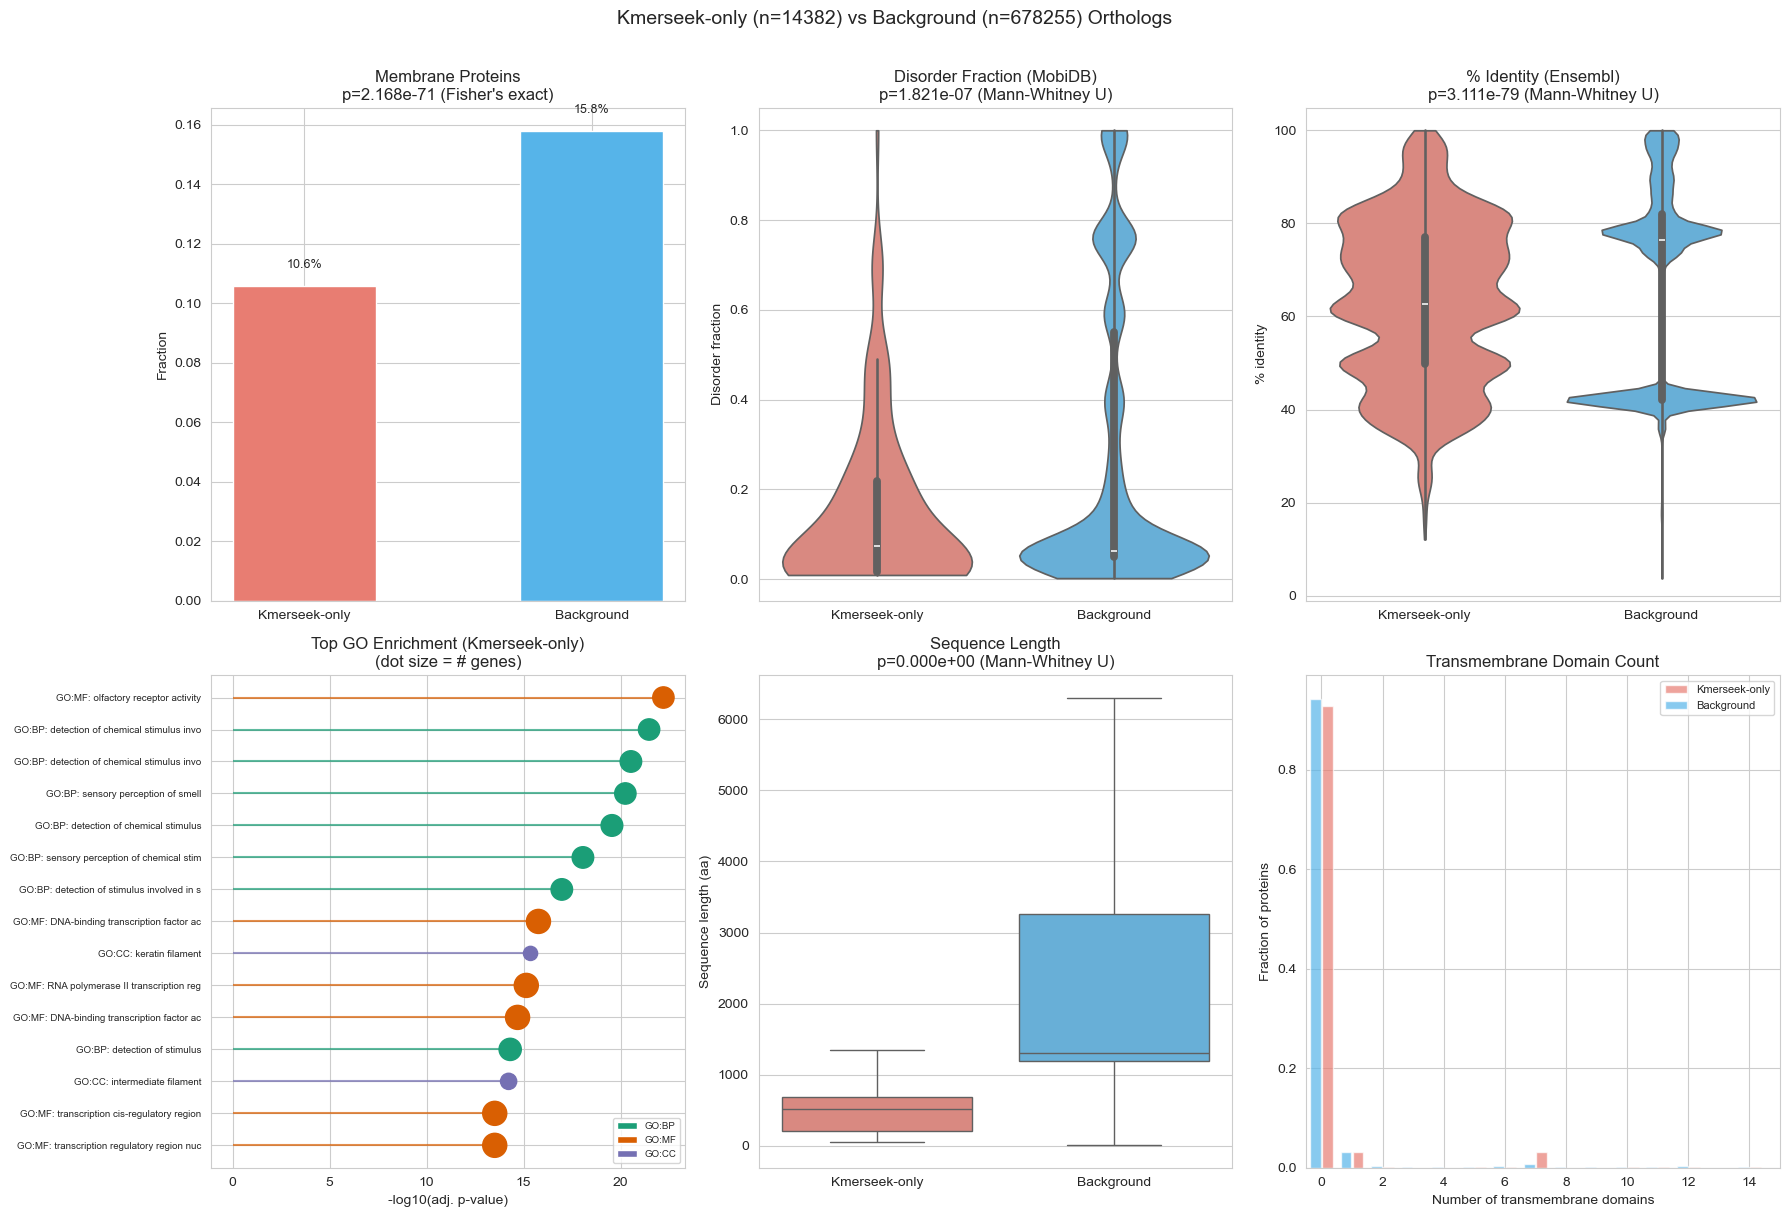

In [29]:
n_ko = len(kmerseek_only_df)
n_bg = len(background_df)

combined = pd.concat([
    kmerseek_only_df.to_pandas().assign(set_label="Kmerseek-only"),
    background_df.to_pandas().assign(set_label="Background"),
], ignore_index=True)

palette = {"Kmerseek-only": "#E87D72", "Background": "#56B4E9"}
order = ["Kmerseek-only", "Background"]

fig, axes = plt.subplots(2, 3, figsize=(18, 12))
fig.suptitle(
    f"Kmerseek-only (n={n_ko}) vs Background (n={n_bg}) Orthologs",
    fontsize=14, y=1.01,
)

# --- Panel 1: Membrane fraction ---
ax = axes[0, 0]
ko_mem_n = int(kmerseek_only_df["is_membrane"].sum())
bg_mem_n = int(background_df["is_membrane"].sum())
ko_frac = ko_mem_n / n_ko
bg_frac = bg_mem_n / n_bg
_, p_mem = fisher_exact([[ko_mem_n, n_ko - ko_mem_n], [bg_mem_n, n_bg - bg_mem_n]])
bars = ax.bar(order, [ko_frac, bg_frac], color=[palette[k] for k in order], width=0.5)
for bar, val in zip(bars, [ko_frac, bg_frac]):
    ax.text(bar.get_x() + bar.get_width() / 2, bar.get_height() + 0.005,
            f"{val:.1%}", ha="center", va="bottom", fontsize=9)
ax.set_ylabel("Fraction")
ax.set_title(f"Membrane Proteins\np={p_mem:.3e} (Fisher's exact)")

# --- Panel 2: Disorder fraction violin ---
ax = axes[0, 1]
dis_data = combined.dropna(subset=["disorder_fraction"])
if len(dis_data) > 10:
    sns.violinplot(data=dis_data, x="set_label", y="disorder_fraction",
                   palette=palette, order=order, ax=ax, cut=0, inner="box")
    ko_v = dis_data[dis_data["set_label"] == "Kmerseek-only"]["disorder_fraction"].values
    bg_v = dis_data[dis_data["set_label"] == "Background"]["disorder_fraction"].values
    p_dis = mannwhitneyu(ko_v, bg_v, alternative="two-sided")[1] if (len(ko_v) > 1 and len(bg_v) > 1) else float("nan")
    ax.set_title(f"Disorder Fraction (MobiDB)\np={p_dis:.3e} (Mann-Whitney U)")
    ax.set_xlabel("")
    ax.set_ylabel("Disorder fraction")
else:
    ax.text(0.5, 0.5, "No MobiDB data", ha="center", va="center", transform=ax.transAxes)
    p_dis = float("nan")

# --- Panel 3: % identity violin ---
ax = axes[0, 2]
pid_data = combined.dropna(subset=["perc_id"])
if len(pid_data) > 10:
    sns.violinplot(data=pid_data, x="set_label", y="perc_id",
                   palette=palette, order=order, ax=ax, cut=0, inner="box")
    ko_v = pid_data[pid_data["set_label"] == "Kmerseek-only"]["perc_id"].values
    bg_v = pid_data[pid_data["set_label"] == "Background"]["perc_id"].values
    p_pid = mannwhitneyu(ko_v, bg_v, alternative="two-sided")[1] if (len(ko_v) > 1 and len(bg_v) > 1) else float("nan")
    ax.set_title(f"% Identity (Ensembl)\np={p_pid:.3e} (Mann-Whitney U)")
    ax.set_xlabel("")
    ax.set_ylabel("% identity")
else:
    ax.text(0.5, 0.5, "No % identity data", ha="center", va="center", transform=ax.transAxes)
    p_pid = float("nan")

# --- Panel 4: Top GO terms (lollipop) ---
ax = axes[1, 0]
sig_go = (
    go_results[go_results["significant"]].sort_values("p_value").head(15).copy()
    if len(go_results) > 0
    else pd.DataFrame()
)
if len(sig_go) > 0:
    source_colors = {"GO:BP": "#1B9E77", "GO:MF": "#D95F02", "GO:CC": "#7570B3"}
    y_pos = np.arange(len(sig_go))
    x_vals = -np.log10(sig_go["p_value"].values)
    dot_colors = [source_colors.get(s, "grey") for s in sig_go["source"]]
    # Stems
    for y, x, color in zip(y_pos, x_vals, dot_colors):
        ax.hlines(y, 0, x, color=color, linewidth=1.5, alpha=0.7)
    # Dots sized by intersection_size (# genes)
    n_genes = sig_go["intersection_size"].values if "intersection_size" in sig_go.columns else np.ones(len(sig_go)) * 10
    dot_sizes = np.clip(n_genes * 4, 20, 300)
    ax.scatter(x_vals, y_pos, s=dot_sizes, c=dot_colors, zorder=3)
    ax.set_yticks(y_pos)
    ax.set_yticklabels(
        [f"{row['source']}: {row['name'][:35]}" for _, row in sig_go.iterrows()],
        fontsize=7,
    )
    ax.invert_yaxis()
    ax.set_xlabel("-log10(adj. p-value)")
    ax.set_title("Top GO Enrichment (Kmerseek-only)\n(dot size = # genes)")
    from matplotlib.patches import Patch
    ax.legend(
        handles=[Patch(facecolor=c, label=s) for s, c in source_colors.items()],
        fontsize=7, loc="lower right",
    )
else:
    ax.text(0.5, 0.5, "No significant GO terms", ha="center", va="center", transform=ax.transAxes)
    ax.set_title("Top GO Enrichment (Kmerseek-only)")

# --- Panel 5: Sequence length boxplot ---
ax = axes[1, 1]
len_data = combined.dropna(subset=["seq_length"])
if len(len_data) > 10:
    sns.boxplot(data=len_data, x="set_label", y="seq_length",
                palette=palette, order=order, ax=ax, showfliers=False)
    ko_v = len_data[len_data["set_label"] == "Kmerseek-only"]["seq_length"].values
    bg_v = len_data[len_data["set_label"] == "Background"]["seq_length"].values
    p_len = mannwhitneyu(ko_v, bg_v, alternative="two-sided")[1] if (len(ko_v) > 1 and len(bg_v) > 1) else float("nan")
    ax.set_title(f"Sequence Length\np={p_len:.3e} (Mann-Whitney U)")
    ax.set_xlabel("")
    ax.set_ylabel("Sequence length (aa)")
else:
    ax.text(0.5, 0.5, "No length data", ha="center", va="center", transform=ax.transAxes)
    p_len = float("nan")

# --- Panel 6: Transmembrane domain count ---
ax = axes[1, 2]
tm_data = combined.dropna(subset=["n_transmembrane"])
if len(tm_data) > 0:
    for label, color in palette.items():
        sub = tm_data[tm_data["set_label"] == label]
        counts = sub["n_transmembrane"].value_counts().sort_index()
        offset = 0.2 if label == "Kmerseek-only" else -0.2
        ax.bar(
            counts.index + offset,
            counts.values / len(sub),
            alpha=0.7, color=color, label=label, width=0.35,
        )
    ax.set_xlabel("Number of transmembrane domains")
    ax.set_ylabel("Fraction of proteins")
    ax.set_title("Transmembrane Domain Count")
    ax.set_xlim(-0.5, 15)
    ax.legend(fontsize=8)

plt.tight_layout()
fig_path = DATA_DIR / f"{PREFIX}kmerseek_only_characterization.png"
plt.savefig(str(fig_path), dpi=300, bbox_inches="tight")
print(f"Figure saved to {fig_path}")
plt.show()


## Pairplot: %identity, %similarity, Disorder — k=24 & k=27, colored by OrthoFinder

For each k-size, take all **kmerseek-detected MGI ortholog pairs** (Bonferroni p < α) and plot
pairwise scatter/KDE of five features, coloured by whether OrthoFinder also found the pair
(analogous to the FoldSeek-vs-KmerSeek pairplots in notebook 068 for the SCOPe benchmark).

Features:
- **%identity** — percent identical AAs in the matched overlap region
- **%similarity** — percent similar AAs (BLOSUM62 positive pairs)
- **disorder fraction** — full-protein intrinsic disorder (MobiDB, human protein)
- **jaccard** — kmerseek jaccard score
- **log10(p)** — log10 of the conservative Bonferroni-corrected Poisson p-value

In [ ]:
# ── Pairplot data: %id, %sim, disorder for k=24, k=27 colored by OrthoFinder ──────────────
# Re-loads both k-sizes including query_subseq/target_subseq for sequence comparison.
# Uses cached MobiDB disorder and existing mgi_ortholog_set / of_pairs.

# BLOSUM62 positive-score pairs (conservative substitutions = "similar")
_BLOSUM62_POS = {
    frozenset(p) for p in [
        ('A','S'),('A','T'),('A','G'),('D','E'),('D','N'),('E','Q'),('E','K'),
        ('N','S'),('N','T'),('Q','K'),('R','K'),('I','L'),('I','V'),('I','M'),
        ('L','V'),('L','M'),('F','Y'),('F','W'),('Y','W'),('H','N'),('H','Q'),
        ('S','T'),('V','M'),
    ]
}
_BLOSUM62_POS |= {frozenset((aa, aa)) for aa in 'ACDEFGHIKLMNPQRSTVWY'}


def pct_id_sim(q_seq: str, t_seq: str):
    """Return (%identity, %similarity) over the matched overlap region."""
    n = min(len(q_seq), len(t_seq))
    if n == 0:
        return np.nan, np.nan
    n_id  = sum(q == t for q, t in zip(q_seq, t_seq))
    n_sim = sum(frozenset((q.upper(), t.upper())) in _BLOSUM62_POS
                for q, t in zip(q_seq, t_seq))
    return 100 * n_id / n, 100 * n_sim / n


_SUBSEQ_COLS = [
    "query_name", "target_name",
    "jaccard", "n_intersecting_hashes", "expected_shared_kmers",
    "human_gene", "mouse_gene", "is_ortholog",
    "query_subseq", "target_subseq",
]


def load_ksize_pairplot_data(ksize: int) -> pd.DataFrame:
    """Load kmerseek TSV for one k-size, compute %id/%sim/disorder for MGI TPs."""
    tsv_path = DATA_DIR / f"ortholog_evaluation.hp.k{ksize}.tsv.gz"
    print(f"\nLoading k={ksize} from {tsv_path.name} ...")

    df_k = pl.read_csv(
        str(tsv_path),
        separator="\t",
        columns=_SUBSEQ_COLS,
        ignore_errors=True,
        null_values=["", "NA", "NaN"],
    )
    print(f"  {len(df_k):,} total pairs")

    # Poisson p-value + conservative Bonferroni (same approach as cell-load-kmerseek)
    k_arr   = df_k["n_intersecting_hashes"].to_numpy()
    lam_arr = df_k["expected_shared_kmers"].cast(pl.Float64).fill_null(0.0).to_numpy()
    pp_k    = poisson.sf(k_arr - 1, np.maximum(lam_arr, 1e-300))
    N_H     = df_k["query_name"].n_unique()
    N_M     = df_k["target_name"].n_unique()
    bonf_k  = np.clip(pp_k * N_H * N_M, 0, 1)

    df_k = df_k.with_columns([
        pl.Series("poisson_p",                   pp_k),
        pl.Series("poisson_p_bonf_conservative", bonf_k),
        pl.col("human_gene").str.to_uppercase().alias("human_upper"),
        pl.col("mouse_gene").str.to_uppercase().alias("mouse_upper"),
    ])

    # MGI ortholog, OrthoFinder, and kmerseek prediction flags
    h_upper = df_k["human_upper"].to_list()
    m_upper = df_k["mouse_upper"].to_list()
    is_mgi = [(h, m) in mgi_ortholog_set for h, m in zip(h_upper, m_upper)]
    is_of  = [(h, m) in of_pairs         for h, m in zip(h_upper, m_upper)]
    km_pred = bonf_k < ALPHA

    df_k = df_k.with_columns([
        pl.Series("is_mgi_ortholog", is_mgi),
        pl.Series("is_orthofinder",  is_of),
        pl.Series("kmerseek_pred",   km_pred),
    ])

    # Filter: kmerseek-detected MGI TPs only
    df_k = df_k.filter(pl.col("kmerseek_pred") & pl.col("is_mgi_ortholog"))
    n_of = int(df_k["is_orthofinder"].sum())
    print(f"  {len(df_k):,} kmerseek-detected MGI orthologs  "
          f"(OrthoFinder also found: {n_of:,} = {100*n_of/max(len(df_k),1):.1f}%)")

    # Disorder lookup via MobiDB cache (human protein only)
    human_ensp     = [str(n).split("|")[0].split(".")[0] for n in df_k["query_name"].to_list()]
    uniprot_accs   = [uniprot_cache.get(p, "") for p in human_ensp]
    disorder_fracs = [mobi_cache.get(acc) if acc else None for acc in uniprot_accs]
    df_k = df_k.with_columns([
        pl.Series("uniprot_acc",       uniprot_accs),
        pl.Series("disorder_fraction", disorder_fracs, dtype=pl.Float64),
    ])

    # Compute %id and %sim from matched subsequences
    pct_ids, pct_sims = [], []
    for row in df_k.iter_rows(named=True):
        q_seq = row["query_subseq"] or ""
        t_seq = row["target_subseq"] or ""
        pid, psim = pct_id_sim(q_seq, t_seq)
        pct_ids.append(pid)
        pct_sims.append(psim)

    df_k = df_k.with_columns([
        pl.Series("pct_identity",   pct_ids,  dtype=pl.Float64),
        pl.Series("pct_similarity", pct_sims, dtype=pl.Float64),
    ])

    pdf = df_k.to_pandas()
    pdf["ksize"] = ksize
    return pdf


pairplot_dfs = {}
for _k in [24, 27]:
    pairplot_dfs[_k] = load_ksize_pairplot_data(_k)


In [ ]:
# ── Pairplot: colored by found-by-OrthoFinder (analogous to 068 FoldSeek pairplots) ───────
PAIRPLOT_FEATS = ["%identity", "%similarity", "disorder fraction", "jaccard", "log10(p)"]
PALETTE_OF = {"also OrthoFinder": "#4DBEEE", "kmerseek-only": "#E87D72"}

for _k in [24, 27]:
    pdf = pairplot_dfs[_k].copy()
    pdf["%identity"]        = pdf["pct_identity"]
    pdf["%similarity"]      = pdf["pct_similarity"]
    pdf["disorder fraction"] = pdf["disorder_fraction"]
    pdf["log10(p)"]          = np.log10(np.maximum(pdf["poisson_p"], 1e-320))
    pdf["found by OrthoFinder"] = pdf["is_orthofinder"].map(
        {True: "also OrthoFinder", False: "kmerseek-only"}
    )

    sub = pdf[PAIRPLOT_FEATS + ["found by OrthoFinder"]].dropna(subset=PAIRPLOT_FEATS)
    print(f"\nk={_k}: {len(sub):,} pairs for pairplot")
    print(sub["found by OrthoFinder"].value_counts().to_string())

    g = sns.pairplot(
        sub,
        hue="found by OrthoFinder",
        hue_order=["also OrthoFinder", "kmerseek-only"],
        palette=PALETTE_OF,
        diag_kind="kde",
        plot_kws=dict(alpha=0.4, s=14, linewidth=0),
        diag_kws=dict(fill=True, alpha=0.5),
    )
    g.figure.suptitle(
        f"Kmerseek-detected MGI orthologs (k={_k}, Bonferroni p<{ALPHA})\n"
        f"colored by: found by OrthoFinder",
        y=1.02, fontsize=12, fontweight="bold",
    )
    plt.tight_layout()
    fig_path = DATA_DIR / f"{PREFIX}pairplot_k{_k}_orthofinder.png"
    plt.savefig(str(fig_path), dpi=150, bbox_inches="tight")
    plt.show()
    print(f"Saved {fig_path.name}")


## Cell 8: Summary Statistics Table

In [30]:
ko_pd = kmerseek_only_df.to_pandas()
bg_pd = background_df.to_pandas()


def safe_mwu(a, b):
    a = [v for v in a if v is not None and not (isinstance(v, float) and np.isnan(v))]
    b = [v for v in b if v is not None and not (isinstance(v, float) and np.isnan(v))]
    if len(a) < 2 or len(b) < 2:
        return float("nan")
    return mannwhitneyu(a, b, alternative="two-sided")[1]


def pct_diff(ko_val, bg_val):
    """Return '+X.X% higher' or '-X.X% lower' string relative to background."""
    if bg_val == 0 or np.isnan(bg_val) or np.isnan(ko_val):
        return "N/A"
    d = (ko_val - bg_val) / abs(bg_val) * 100
    direction = "higher" if d >= 0 else "lower"
    return f"{abs(d):.1f}% {direction}"


ko_mem_n = int(ko_pd["is_membrane"].sum())
bg_mem_n = int(bg_pd["is_membrane"].sum())
ko_mem_frac = ko_mem_n / n_ko
bg_mem_frac = bg_mem_n / n_bg
_, p_mem = fisher_exact([[ko_mem_n, n_ko - ko_mem_n], [bg_mem_n, n_bg - bg_mem_n]])

ko_dis_n = int(ko_pd["has_disordered_regions"].sum())
bg_dis_n = int(bg_pd["has_disordered_regions"].sum())
ko_dis_frac = ko_dis_n / n_ko
bg_dis_frac = bg_dis_n / n_bg
_, p_dis_binary = fisher_exact([[ko_dis_n, n_ko - ko_dis_n], [bg_dis_n, n_bg - bg_dis_n]])

ko_mobi = ko_pd["disorder_fraction"].dropna().values
bg_mobi = bg_pd["disorder_fraction"].dropna().values
p_mobi = safe_mwu(ko_mobi, bg_mobi)
ko_mobi_med = np.median(ko_mobi) if len(ko_mobi) else float("nan")
bg_mobi_med = np.median(bg_mobi) if len(bg_mobi) else float("nan")

ko_pid = ko_pd["perc_id"].dropna().values
bg_pid = bg_pd["perc_id"].dropna().values
p_pid = safe_mwu(ko_pid, bg_pid)
ko_pid_med = np.median(ko_pid) if len(ko_pid) else float("nan")
bg_pid_med = np.median(bg_pid) if len(bg_pid) else float("nan")

ko_ln = ko_pd["seq_length"].dropna().values
bg_ln = bg_pd["seq_length"].dropna().values
p_ln = safe_mwu(ko_ln, bg_ln)
ko_ln_med = np.median(ko_ln) if len(ko_ln) else float("nan")
bg_ln_med = np.median(bg_ln) if len(bg_ln) else float("nan")

summary_rows = [
    {
        "Feature": "% membrane proteins",
        f"Kmerseek-only (n={n_ko})": f"{100 * ko_mem_frac:.1f}%",
        f"Background (n={n_bg})": f"{100 * bg_mem_frac:.1f}%",
        "KO vs BG": pct_diff(ko_mem_frac, bg_mem_frac),
        "p-value": f"{p_mem:.3e}",
        "Test": "Fisher's exact",
    },
    {
        "Feature": "% with disordered regions (UniProt)",
        f"Kmerseek-only (n={n_ko})": f"{100 * ko_dis_frac:.1f}%",
        f"Background (n={n_bg})": f"{100 * bg_dis_frac:.1f}%",
        "KO vs BG": pct_diff(ko_dis_frac, bg_dis_frac),
        "p-value": f"{p_dis_binary:.3e}",
        "Test": "Fisher's exact",
    },
    {
        "Feature": "Median disorder fraction (MobiDB)",
        f"Kmerseek-only (n={n_ko})": f"{ko_mobi_med:.3f}" if not np.isnan(ko_mobi_med) else "N/A",
        f"Background (n={n_bg})": f"{bg_mobi_med:.3f}" if not np.isnan(bg_mobi_med) else "N/A",
        "KO vs BG": pct_diff(ko_mobi_med, bg_mobi_med),
        "p-value": f"{p_mobi:.3e}",
        "Test": "Mann-Whitney U",
    },
    {
        "Feature": "Median % identity (Ensembl)",
        f"Kmerseek-only (n={n_ko})": f"{ko_pid_med:.4f}" if not np.isnan(ko_pid_med) else "N/A",
        f"Background (n={n_bg})": f"{bg_pid_med:.4f}" if not np.isnan(bg_pid_med) else "N/A",
        "KO vs BG": pct_diff(ko_pid_med, bg_pid_med),
        "p-value": f"{p_pid:.3e}",
        "Test": "Mann-Whitney U",
    },
    {
        "Feature": "Median sequence length (aa)",
        f"Kmerseek-only (n={n_ko})": f"{ko_ln_med:.0f}" if not np.isnan(ko_ln_med) else "N/A",
        f"Background (n={n_bg})": f"{bg_ln_med:.0f}" if not np.isnan(bg_ln_med) else "N/A",
        "KO vs BG": pct_diff(ko_ln_med, bg_ln_med),
        "p-value": f"{p_ln:.3e}",
        "Test": "Mann-Whitney U",
    },
]

summary_df = pd.DataFrame(summary_rows)
print(summary_df.to_string(index=False))

summary_path = DATA_DIR / f"{PREFIX}summary_statistics.csv"
summary_df.to_csv(str(summary_path), index=False)
print(f"\nSaved to {summary_path}")

                            Feature Kmerseek-only (n=14382) Background (n=678255)     KO vs BG   p-value           Test
                % membrane proteins                   10.6%                 15.8%  33.0% lower 2.168e-71 Fisher's exact
% with disordered regions (UniProt)                   20.4%                 93.4%  78.2% lower 0.000e+00 Fisher's exact
  Median disorder fraction (MobiDB)                   0.074                 0.063 17.5% higher 1.821e-07 Mann-Whitney U
        Median % identity (Ensembl)                 62.6866               76.5193  18.1% lower 3.111e-79 Mann-Whitney U
        Median sequence length (aa)                     522                  1301  59.9% lower 0.000e+00 Mann-Whitney U

Saved to /Users/olga/data/gencode/results-human-mouse-orthologs/120_summary_statistics.csv


In [31]:
annotation_cols = [
    "human_gene_name", "mouse_gene_name", "human_protein_id", "human_gene_id",
    "uniprot_acc", "set_label", "poisson_p",
    "seq_length", "subcellular_location", "is_membrane", "is_secreted", "is_nuclear",
    "n_transmembrane", "n_disordered_regions", "has_disordered_regions",
    "disorder_fraction", "perc_id", "keywords",
]

combined_ann = pl.concat([
    kmerseek_only_df.select([c for c in annotation_cols if c in kmerseek_only_df.columns]),
    background_df.select([c for c in annotation_cols if c in background_df.columns]),
])

ann_path = DATA_DIR / f"{PREFIX}annotation_results.csv"
combined_ann.write_csv(str(ann_path))
print(f"Saved {len(combined_ann):,} rows to {ann_path}")
combined_ann.head(5)

Saved 692,637 rows to /Users/olga/data/gencode/results-human-mouse-orthologs/120_annotation_results.csv


human_gene_name,mouse_gene_name,human_protein_id,human_gene_id,uniprot_acc,set_label,poisson_p,seq_length,subcellular_location,is_membrane,is_secreted,is_nuclear,n_transmembrane,n_disordered_regions,has_disordered_regions,disorder_fraction,perc_id,keywords
str,str,str,str,str,str,f64,i64,str,bool,bool,bool,i64,i64,bool,f64,f64,str
"""AADACL4""","""Aadacl4fm1""","""ENSP00000365395""","""ENSG00000204518""","""Q5VUY2""","""kmerseek_only""",2.1435e-82,407,"""Membrane""",true,false,false,1,0,false,null,64.1278,"""Glycoprotein; Hydrolase; Membr…"
"""AADACL4""","""Aadacl4fm1""","""ENSP00000365395""","""ENSG00000204518""","""Q5VUY2""","""kmerseek_only""",2.1435e-82,407,"""Membrane""",true,false,false,1,0,false,null,64.1278,"""Glycoprotein; Hydrolase; Membr…"
"""AADACL4""","""Aadacl4fm1""","""ENSP00000365395""","""ENSG00000204518""","""Q5VUY2""","""kmerseek_only""",2.1435e-82,407,"""Membrane""",true,false,false,1,0,false,null,64.1278,"""Glycoprotein; Hydrolase; Membr…"
"""AADACL4""","""Aadacl4fm1""","""ENSP00000365395""","""ENSG00000204518""","""Q5VUY2""","""kmerseek_only""",2.1435e-82,407,"""Membrane""",true,false,false,1,0,false,null,64.1278,"""Glycoprotein; Hydrolase; Membr…"
"""AADACL4""","""Aadacl4fm1""","""ENSP00000365395""","""ENSG00000204518""","""Q5VUY2""","""kmerseek_only""",2.1435e-82,407,"""Membrane""",true,false,false,1,0,false,null,64.1278,"""Glycoprotein; Hydrolase; Membr…"


## Cell 9: Three-Way GO Enrichment Comparison

Compare GO enrichment across three gene sets relative to all MGI-confirmed orthologs:
- **Kmerseek-only**: found by Kmerseek (conservative Bonferroni) but NOT OrthoFinder
- **Shared TPs**: found by BOTH Kmerseek and OrthoFinder
- **OrthoFinder-only**: found by OrthoFinder but NOT Kmerseek (conservative)

In [32]:
GO3_CACHE = DATA_DIR / f"{PREFIX}go_enrichment_3way.json"

# Build the three gene sets
background_genes_all = [
    g for g in df.filter(pl.col("is_mgi_ortholog"))["human_gene"].unique().drop_nulls().to_list() if g
]

shared_tp = df.filter(pl.col("kmerseek_pred") & pl.col("is_mgi_ortholog") & pl.col("is_orthofinder"))
of_only = df.filter(~pl.col("kmerseek_pred") & pl.col("is_mgi_ortholog") & pl.col("is_orthofinder"))

gene_sets = {
    "Kmerseek-only":     [g for g in kmerseek_only_df["human_gene_name"].unique().drop_nulls().to_list() if g],
    "Shared TPs":        [g for g in shared_tp["human_gene"].unique().drop_nulls().to_list() if g],
    "OrthoFinder-only":  [g for g in of_only["human_gene"].unique().drop_nulls().to_list() if g],
}
for k, v in gene_sets.items():
    print(f"{k}: {len(v):,} genes")

# Load or run g:Profiler for each set
if GO3_CACHE.exists():
    with open(GO3_CACHE) as f:
        go3_raw = json.load(f)
    go3_results = {k: pd.DataFrame(v) for k, v in go3_raw.items()}
    print("Loaded 3-way GO results from cache")
else:
    go3_results = {}
    api_success = True  # Flag to track network success

    for label, genes in gene_sets.items():
        print(f"Running g:Profiler for '{label}' ({len(genes)} genes)...")
        try:
            res = gp.profile(
                organism="hsapiens",
                query=genes,
                background=background_genes_all,
                sources=["GO:BP", "GO:MF", "GO:CC"],
                significance_threshold_method="fdr",
                user_threshold=0.05,
                no_iea=False,
            )
            go3_results[label] = res
            print(f"  → {len(res):,} terms, {res['significant'].sum():,} significant")
        except Exception as exc:
            print(f"  ERROR: {exc}")
            api_success = False  # Mark that it failed
            go3_results[label] = pd.DataFrame(columns=["source", "name", "p_value", "significant"])
            break # Stop immediately since the network is down

    if api_success:
        with open(GO3_CACHE, "w") as f:
            json.dump({k: v.to_dict(orient="records") for k, v in go3_results.items()}, f)
        print("Saved 3-way GO cache")
    else:
        print("Network error prevented cache from saving. Check your internet connection.")

Kmerseek-only: 597 genes
Shared TPs: 15,748 genes
OrthoFinder-only: 374 genes
Loaded 3-way GO results from cache


Saved to /Users/olga/data/gencode/results-human-mouse-orthologs/120_go_enrichment_3way.png


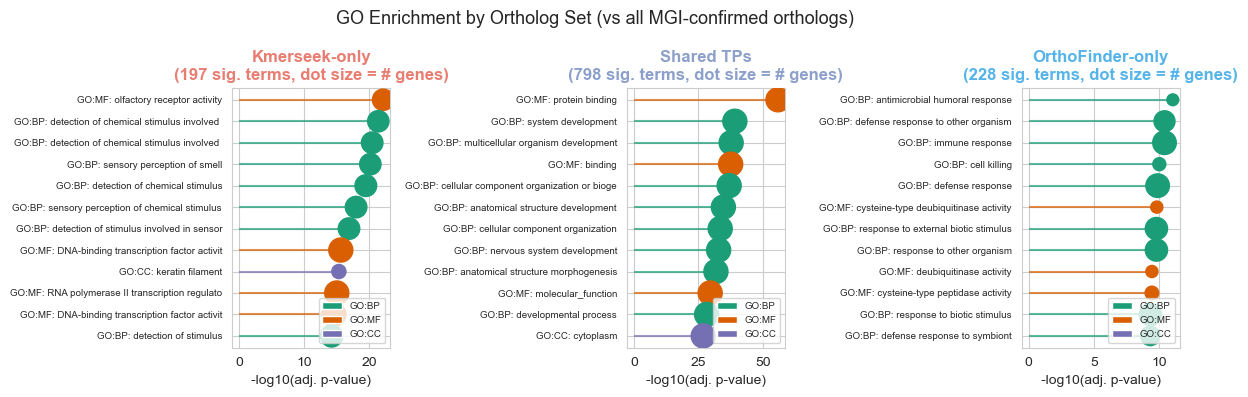


=== Top GO terms unique to Kmerseek-only (not significant in Shared TPs) ===
source                                                                            name      p_value
 GO:MF                                                     olfactory receptor activity 8.093666e-23
 GO:BP          detection of chemical stimulus involved in sensory perception of smell 4.435683e-22
 GO:BP                   detection of chemical stimulus involved in sensory perception 3.839618e-21
 GO:BP                                                     sensory perception of smell 7.375210e-21
 GO:BP                                                  detection of chemical stimulus 3.645649e-20
 GO:BP                                         sensory perception of chemical stimulus 1.132095e-18
 GO:BP                            detection of stimulus involved in sensory perception 1.383257e-17
 GO:MF                                       DNA-binding transcription factor activity 2.500679e-16
 GO:CC                

In [37]:
# Plot 3-way GO enrichment: top 12 sig terms per set, side by side (lollipop)
set_labels = ["Kmerseek-only", "Shared TPs", "OrthoFinder-only"]
set_colors = {"Kmerseek-only": "#E87D72", "Shared TPs": "#8DA0CB", "OrthoFinder-only": "#56B4E9"}
source_colors = {"GO:BP": "#1B9E77", "GO:MF": "#D95F02", "GO:CC": "#7570B3"}

fig, axes = plt.subplots(1, 3, figsize=(12, 4), sharey=False)
fig.suptitle("GO Enrichment by Ortholog Set (vs all MGI-confirmed orthologs)", fontsize=13)

for ax, label in zip(axes, set_labels):
    res = go3_results.get(label, pd.DataFrame())
    if len(res) == 0 or "significant" not in res.columns:
        ax.text(0.5, 0.5, "No data", ha="center", va="center", transform=ax.transAxes)
        ax.set_title(label)
        continue
    sig = res[res["significant"]].sort_values("p_value").head(12).copy()
    if len(sig) == 0:
        ax.text(0.5, 0.5, "No significant terms", ha="center", va="center", transform=ax.transAxes)
        ax.set_title(f"{label}\n(0 sig. terms)")
        continue
    y_pos = np.arange(len(sig))
    x_vals = -np.log10(sig["p_value"].values)
    dot_colors = [source_colors.get(s, "grey") for s in sig["source"]]
    # Stems
    for y, x, color in zip(y_pos, x_vals, dot_colors):
        ax.hlines(y, 0, x, color=color, linewidth=1.5, alpha=0.7)
    # Dots sized by intersection_size (# genes)
    n_genes = sig["intersection_size"].values if "intersection_size" in sig.columns else np.ones(len(sig)) * 10
    dot_sizes = np.clip(n_genes * 4, 20, 300)
    ax.scatter(x_vals, y_pos, s=dot_sizes, c=dot_colors, zorder=3)
    ax.set_yticks(y_pos)
    ax.set_yticklabels(
        [f"{row['source']}: {row['name'][:40]}" for _, row in sig.iterrows()],
        fontsize=7,
    )
    ax.invert_yaxis()
    ax.set_xlabel("-log10(adj. p-value)")
    n_sig = res["significant"].sum()
    ax.set_title(
        f"{label}\n({n_sig} sig. terms, dot size = # genes)",
        color=set_colors[label], fontweight="bold",
    )
    from matplotlib.patches import Patch
    ax.legend(
        handles=[Patch(facecolor=c, label=s) for s, c in source_colors.items()],
        fontsize=7, loc="lower right",
    )

plt.tight_layout()
fig_path = DATA_DIR / f"{PREFIX}go_enrichment_3way.png"
plt.savefig(str(fig_path), dpi=300, bbox_inches="tight")
print(f"Saved to {fig_path}")
plt.show()

# Print top 5 unique-to-Kmerseek-only terms (not significant in Shared TPs)
print("\n=== Top GO terms unique to Kmerseek-only (not significant in Shared TPs) ===")
ko_sig = go3_results.get("Kmerseek-only", pd.DataFrame())
sh_sig = go3_results.get("Shared TPs", pd.DataFrame())
if len(ko_sig) and "significant" in ko_sig.columns and len(sh_sig):
    shared_sig_names = set(sh_sig[sh_sig["significant"]]["native"].tolist()) if "native" in sh_sig.columns else set()
    ko_only_terms = ko_sig[ko_sig["significant"]].copy()
    if "native" in ko_only_terms.columns:
        ko_only_terms = ko_only_terms[~ko_only_terms["native"].isin(shared_sig_names)]
    print(ko_only_terms.sort_values("p_value")[["source", "name", "p_value"]].head(10).to_string(index=False))


## Summary

In [34]:
print("=" * 70)
print("NOTEBOOK 120: Kmerseek-Only Orthologs — Conservative Bonferroni Threshold")
print("=" * 70)
print(f"\nMultiple testing correction: Bonferroni over all {N_TOTAL_CONSERVATIVE:,} possible pairs")
print(f"  N human proteins : {N_HUMAN:,}")
print(f"  N mouse proteins : {N_MOUSE:,}")
print(f"  Raw p threshold  : {BONF_THRESHOLD:.2e}  (α={ALPHA} / N_TOTAL)")
print()
print("Ortholog sets:")
print(f"  OrthoFinder TPs (background) : {n_bg:,}")
print(f"  Kmerseek TPs (conservative)  : {len(kmerseek_tps):,}")
print(f"  Kmerseek-only (not in OF)    : {n_ko:,}  ({100*n_ko/len(kmerseek_tps):.1f}% of Kmerseek TPs)")
print()

print("=== Characterization of Kmerseek-only vs Background ===")
display(summary_df)
print()

# GO enrichment per set
_go_cols = ["source", "name", "p_value", "intersection_size", "term_size"]
for _set_name in ["Kmerseek-only", "Shared TPs", "OrthoFinder-only"]:
    _res = go3_results.get(_set_name, pd.DataFrame())
    if len(_res) == 0 or "significant" not in _res.columns:
        print(f"=== {_set_name}: no GO results ===\n")
        continue
    _sig = _res[_res["significant"]].sort_values("p_value")
    _n_sig = len(_sig)
    print(f"=== Top GO terms: {_set_name} ({_n_sig} significant total) ===")
    _cols = [c for c in _go_cols if c in _sig.columns]
    display(_sig[_cols].head(10).reset_index(drop=True))
    print()

# Kmerseek-only terms not significant in Shared TPs
_ko_res = go3_results.get("Kmerseek-only", pd.DataFrame())
_sh_res = go3_results.get("Shared TPs", pd.DataFrame())
if len(_ko_res) and "significant" in _ko_res.columns and len(_sh_res) and "significant" in _sh_res.columns:
    _shared_ids = set(_sh_res[_sh_res["significant"]]["native"].tolist()) if "native" in _sh_res.columns else set()
    _ko_unique = _ko_res[_ko_res["significant"]].copy()
    if "native" in _ko_unique.columns:
        _ko_unique = _ko_unique[~_ko_unique["native"].isin(_shared_ids)]
    _cols = [c for c in _go_cols if c in _ko_unique.columns]
    print(f"=== GO terms unique to Kmerseek-only (not in Shared TPs, {len(_ko_unique)} total) ===")
    display(_ko_unique.sort_values("p_value")[_cols].head(10).reset_index(drop=True))
    print()

print(f"Outputs saved to: {DATA_DIR}")
print(f"  {PREFIX}kmerseek_only_pairs.csv")
print(f"  {PREFIX}annotation_results.csv")
print(f"  {PREFIX}kmerseek_only_characterization.png")
print(f"  {PREFIX}go_enrichment_3way.png")
print("=" * 70)


NOTEBOOK 120: Kmerseek-Only Orthologs — Conservative Bonferroni Threshold

Multiple testing correction: Bonferroni over all 414,819,328 possible pairs
  N human proteins : 19,712
  N mouse proteins : 21,044
  Raw p threshold  : 2.41e-12  (α=0.001 / N_TOTAL)

Ortholog sets:
  OrthoFinder TPs (background) : 678,255
  Kmerseek TPs (conservative)  : 692,006
  Kmerseek-only (not in OF)    : 14,382  (2.1% of Kmerseek TPs)

=== Characterization of Kmerseek-only vs Background ===


,Feature,Kmerseek-only (n=14382),Background (n=678255),KO vs BG,p-value,Test
0,% membrane proteins,10.6%,15.8%,33.0% lower,2.168e-71,Fisher's exact
1,% with disordered regions (UniProt),20.4%,93.4%,78.2% lower,0.000e+00,Fisher's exact
2,Median disorder fraction (MobiDB),0.074,0.063,17.5% higher,1.821e-07,Mann-Whitney U
3,Median % identity (Ensembl),62.6866,76.5193,18.1% lower,3.111e-79,Mann-Whitney U
4,Median sequence length (aa),522,1301,59.9% lower,0.000e+00,Mann-Whitney U



=== Top GO terms: Kmerseek-only (197 significant total) ===


,source,name,p_value,intersection_size,term_size
0,GO:MF,olfactory receptor activity,8.093666e-23,59,329
1,GO:BP,detection of chemical stimulus involved in sen...,4.435683e-22,59,331
2,GO:BP,detection of chemical stimulus involved in sen...,3.839618e-21,60,361
3,GO:BP,sensory perception of smell,7.375210e-21,59,356
4,GO:BP,detection of chemical stimulus,3.645649e-20,61,394
5,GO:BP,sensory perception of chemical stimulus,1.132095e-18,60,409
6,GO:BP,detection of stimulus involved in sensory perc...,1.383257e-17,60,431
7,GO:MF,DNA-binding transcription factor activity,2.500679e-16,102,1144
8,GO:CC,keratin filament,4.956548e-16,26,80
9,GO:MF,RNA polymerase II transcription regulatory reg...,1.042646e-15,98,1101



=== Top GO terms: Shared TPs (798 significant total) ===


...


=== Top GO terms: OrthoFinder-only (228 significant total) ===


,source,name,p_value,intersection_size,term_size
0,GO:BP,antimicrobial humoral response,8.845176e-12,18,75
1,GO:BP,defense response to other organism,3.823894e-11,57,976
2,GO:BP,immune response,3.823894e-11,72,1441
3,GO:BP,cell killing,9.556767e-11,22,150
4,GO:BP,defense response,1.289146e-10,72,1502
5,GO:MF,cysteine-type deubiquitinase activity,1.488022e-10,19,111
6,GO:BP,response to external biotic stimulus,1.593012e-10,64,1252
7,GO:BP,response to other organism,1.593012e-10,64,1250
8,GO:MF,deubiquitinase activity,3.542151e-10,19,121
9,GO:MF,cysteine-type peptidase activity,3.542151e-10,24,210



=== GO terms unique to Kmerseek-only (not in Shared TPs, 197 total) ===


,source,name,p_value,intersection_size,term_size
0,GO:MF,olfactory receptor activity,8.093666e-23,59,329
1,GO:BP,detection of chemical stimulus involved in sen...,4.435683e-22,59,331
2,GO:BP,detection of chemical stimulus involved in sen...,3.839618e-21,60,361
3,GO:BP,sensory perception of smell,7.375210e-21,59,356
4,GO:BP,detection of chemical stimulus,3.645649e-20,61,394
5,GO:BP,sensory perception of chemical stimulus,1.132095e-18,60,409
6,GO:BP,detection of stimulus involved in sensory perc...,1.383257e-17,60,431
7,GO:MF,DNA-binding transcription factor activity,2.500679e-16,102,1144
8,GO:CC,keratin filament,4.956548e-16,26,80
9,GO:MF,RNA polymerase II transcription regulatory reg...,1.042646e-15,98,1101



Outputs saved to: /Users/olga/data/gencode/results-human-mouse-orthologs
  120_kmerseek_only_pairs.csv
  120_annotation_results.csv
  120_kmerseek_only_characterization.png
  120_go_enrichment_3way.png
